In [30]:


# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
import subprocess, sys

for pkg in ["pyarrow>=14.0.0", "scipy>=1.11.0", "tqdm>=4.66.0"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# ============================================================
#  IMPORTS
# ============================================================
import gc, os, json, uuid, hashlib, datetime, warnings, math, random, re
from collections import deque
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.linalg import cholesky
from scipy.fft import fft, ifft
from tqdm import tqdm

warnings.filterwarnings("ignore")

MASTER_SEED: int = 42
rng = np.random.default_rng(MASTER_SEED)
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

TOTAL_ROWS = 1_000_000
CHUNK_SIZE = 25_000
NUM_CHUNKS: int = TOTAL_ROWS // CHUNK_SIZE  # 40

OUTPUT_DIR: str = "/content/hinglish_contract_flow"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
#  LEGAL KNOWLEDGE BASE
# ============================================================

STATUTE_MAP: Dict[str, Dict[str, List[str]]] = {
    "Punjab": {
        "agricultural_lease": [
            "Punjab Tenancy Act 1887",
            "Punjab Land Revenue Act 1887",
            "Punjab Security of Land Tenures Act 1953",
            "Punjab Preservation of Sub-Soil Water Act 2009",
        ],
        "commercial_rental": [
            "East Punjab Urban Rent Restriction Act 1949",
            "Punjab Shops and Commercial Establishments Act 1958",
            "Transfer of Property Act 1882 S.105",
        ],
        "logistics_partnership": [
            "Indian Partnership Act 1932",
            "Carriage by Road Act 2007",
            "Motor Vehicles Act 1988",
        ],
        "cold_storage": [
            "Punjab Cold Storage (Regulation) Act 1976",
            "Food Safety and Standards Act 2006",
            "Warehousing Development and Regulatory Authority Act 2007",
        ],
        "machinery_lease": [
            "Transfer of Property Act 1882",
            "Sale of Goods Act 1930 S.9",
            "Punjab Agricultural Machinery (Hire) Rules 2018",
        ],
        "water_sharing": [
            "Punjab Irrigation and Drainage Authority Act 1997",
            "Water (Prevention and Control of Pollution) Act 1974",
        ],
    },
    "Haryana": {
        "agricultural_lease": [
            "Haryana Ceiling on Land Holdings Act 1972",
            "Punjab Tenancy Act 1887 (as applicable to Haryana)",
            "Haryana Land Revenue Act 1967",
            "Model Agricultural Land Leasing Act 2016 (State Adaptation)",
        ],
        "commercial_rental": [
            "Haryana Urban (Control of Rent and Eviction) Act 1973",
            "Haryana Shops and Commercial Establishments Act 1958",
            "Transfer of Property Act 1882",
        ],
        "logistics_partnership": [
            "Indian Partnership Act 1932",
            "Carriage by Road Act 2007",
            "Haryana Motor Vehicles Rules 1993",
        ],
        "cold_storage": [
            "Haryana Cold Storage Policy 2021",
            "Warehousing Development and Regulatory Authority Act 2007",
            "Food Safety and Standards Act 2006",
        ],
        "machinery_lease": [
            "Transfer of Property Act 1882",
            "Haryana Agricultural Machinery (Regulation) Rules 2019",
        ],
        "water_sharing": [
            "Haryana Irrigation Act 1974",
            "Inter-State Water Disputes Act 1956",
        ],
    },
    "Rajasthan": {
        "agricultural_lease": [
            "Rajasthan Tenancy Act 1955",
            "Rajasthan Land Revenue Act 1956",
            "Rajasthan Colonization Act 1954",
        ],
        "commercial_rental": [
            "Rajasthan Premises (Control of Rent and Eviction) Act 1950",
            "Rajasthan Shops and Commercial Establishments Act 1958",
            "Transfer of Property Act 1882",
        ],
        "logistics_partnership": [
            "Indian Partnership Act 1932",
            "Rajasthan Motor Vehicles Taxation Act 1951",
            "Carriage by Road Act 2007",
        ],
        "cold_storage": [
            "Warehousing Development and Regulatory Authority Act 2007",
            "Rajasthan Agricultural Produce Markets Act 1961",
            "Food Safety and Standards Act 2006",
        ],
        "machinery_lease": [
            "Transfer of Property Act 1882",
            "Rajasthan Agricultural Machinery Rules 2002",
        ],
        "water_sharing": [
            "Rajasthan Irrigation and Drainage Act 1954",
            "Rajasthan Ground Water Act 1999",
        ],
    },
    "Maharashtra": {
        "agricultural_lease": [
            "Maharashtra Tenancy and Agricultural Lands Act 1948",
            "Maharashtra Land Revenue Code 1966",
            "Bombay Prevention of Fragmentation and Consolidation of Holdings Act 1947",
        ],
        "commercial_rental": [
            "Maharashtra Rent Control Act 1999",
            "Maharashtra Shops and Establishments (Regulation of Employment and Conditions of Service) Act 2017",
            "Transfer of Property Act 1882",
        ],
        "logistics_partnership": [
            "Indian Partnership Act 1932",
            "Carriage by Road Act 2007",
            "Motor Vehicles Act 1988",
        ],
        "cold_storage": [
            "Maharashtra Cold Storage (Regulation) Order 1980",
            "Warehousing Development and Regulatory Authority Act 2007",
            "Food Safety and Standards Act 2006",
        ],
        "machinery_lease": [
            "Transfer of Property Act 1882",
            "Maharashtra Agricultural Machinery Hire Scheme 2015",
        ],
        "water_sharing": [
            "Maharashtra Irrigation Act 1976",
            "Maharashtra Ground Water (Development and Management) Act 2009",
        ],
    },
    "Uttar_Pradesh": {
        "agricultural_lease": [
            "Uttar Pradesh Zamindari Abolition and Land Reforms Act 1950",
            "Uttar Pradesh Revenue Code 2006",
            "UP Land Revenue Act 1901",
            "Model Agricultural Land Leasing Act 2016 (UP Adaptation)",
        ],
        "commercial_rental": [
            "Uttar Pradesh Urban Buildings (Regulation of Letting, Rent and Eviction) Act 1972",
            "Transfer of Property Act 1882",
            "UP Shops and Commercial Establishments Act 1962",
        ],
        "logistics_partnership": [
            "Indian Partnership Act 1932",
            "Carriage by Road Act 2007",
            "UP Motor Vehicles Special Provisions Act 1976",
        ],
        "cold_storage": [
            "UP Cold Storage Act 1976",
            "Warehousing Development and Regulatory Authority Act 2007",
            "Food Safety and Standards Act 2006",
        ],
        "machinery_lease": [
            "Transfer of Property Act 1882",
            "UP Agricultural Machinery (Hire and Maintenance) Rules 2018",
        ],
        "water_sharing": [
            "Uttar Pradesh Irrigation Act 1901",
            "UP Ground Water (Management and Regulation) Act 2019",
        ],
    },
}

STATE_WEIGHTS: Dict[str, float] = {
    "Punjab": 0.22, "Haryana": 0.18, "Rajasthan": 0.15,
    "Maharashtra": 0.28, "Uttar_Pradesh": 0.17,
}

DISPUTE_TYPE_WEIGHTS: Dict[str, Dict[str, float]] = {
    "Punjab":        {"agricultural_lease": 0.40, "commercial_rental": 0.25, "logistics_partnership": 0.15, "cold_storage": 0.10, "machinery_lease": 0.07, "water_sharing": 0.03},
    "Haryana":       {"agricultural_lease": 0.38, "commercial_rental": 0.22, "logistics_partnership": 0.18, "cold_storage": 0.10, "machinery_lease": 0.08, "water_sharing": 0.04},
    "Rajasthan":     {"agricultural_lease": 0.35, "commercial_rental": 0.28, "logistics_partnership": 0.16, "cold_storage": 0.09, "machinery_lease": 0.08, "water_sharing": 0.04},
    "Maharashtra":   {"agricultural_lease": 0.20, "commercial_rental": 0.40, "logistics_partnership": 0.22, "cold_storage": 0.08, "machinery_lease": 0.07, "water_sharing": 0.03},
    "Uttar_Pradesh": {"agricultural_lease": 0.42, "commercial_rental": 0.23, "logistics_partnership": 0.17, "cold_storage": 0.08, "machinery_lease": 0.07, "water_sharing": 0.03},
}

STAGE_NAMES: List[str] = [
    "Draft_Circulated", "Clause_Negotiation", "Counter_Offer_Filed",
    "Escalation_Initiated", "Mediator_Appointed", "Award_Issued",
    "Compliance_Monitoring", "Terminated",
]

BASE_TRANSITION_MATRIX: np.ndarray = np.array([
    [0.00, 0.70, 0.20, 0.05, 0.00, 0.00, 0.00, 0.05],
    [0.00, 0.00, 0.55, 0.20, 0.05, 0.00, 0.00, 0.20],
    [0.00, 0.00, 0.00, 0.35, 0.20, 0.00, 0.00, 0.45],
    [0.00, 0.00, 0.00, 0.00, 0.65, 0.10, 0.00, 0.25],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.55, 0.20, 0.25],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.75, 0.25],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00],
])

FINAL_OUTCOMES: List[str] = [
    "Mutual_Settlement", "Lok_Adalat_Referral", "Mediation_Pending",
    "Arbitration_Award_Complainant", "Arbitration_Award_Respondent",
    "Judicial_Referral_District_Court",
]

VALIDITY_LABELS: List[str] = [
    "Fully_Enforceable", "Partially_Enforceable",
    "Voidable_at_Option", "Void_ab_initio", "Sub_Judice",
]

LEGAL_INSTITUTIONS: Dict[str, str] = {
    "Lok_Adalat_Referral": "Lok Adalat (National Legal Services Authority)",
    "Mediation_Pending": "District Mediation Centre",
    "Arbitration_Award_Complainant": "Statutory Arbitration Tribunal",
    "Arbitration_Award_Respondent": "Statutory Arbitration Tribunal",
    "Mutual_Settlement": "Out-of-Court Settlement",
    "Judicial_Referral_District_Court": "Civil District Court",
}

AMBIGUITY_CLAUSE_TYPES: List[str] = [
    "payment timeline clause", "security deposit refund clause",
    "occupancy termination notice clause", "crop-type restriction clause",
    "force majeure interpretation clause", "sub-leasing restriction clause",
    "penalty computation clause", "escalation mechanism clause",
    "maintenance responsibility clause", "dispute resolution jurisdiction clause",
    "oral amendment incorporation clause", "harvesting rights clause",
    "water usage allocation clause", "machinery handover condition clause",
    "cold storage liability clause",
]

DIALECT_MARKERS: Dict[str, Dict[str, List[str]]] = {
    "Punjab":        {"affirmative": ["haan ji", "bilkul theek", "sahi hai", "pakka"], "negative": ["nahi ji", "bilkul nahi", "galat hai"], "address": ["saab ji", "bhai sahib", "ji huzoor"], "intensifier": ["bahut zyada", "ekdum", "poora"]},
    "Haryana":       {"affirmative": ["aao bhai", "sahi baat", "theek se"], "negative": ["nai bhai", "hona nai", "thik nai lag ra"], "address": ["bhai", "tau", "chaudhary sahib"], "intensifier": ["ghabra mat", "poora poora"]},
    "Rajasthan":     {"affirmative": ["haan sa", "theek chhe", "bilkul sahi"], "negative": ["nahi sa", "manzoor nahi"], "address": ["maharaj", "sa", "ji sa"], "intensifier": ["bahut hi zyada", "seedha"]},
    "Maharashtra":   {"affirmative": ["haan baba", "theek ahe", "sahi aahe"], "negative": ["nahi baba", "chukeeche aahe"], "address": ["saheb", "bhai", "anna"], "intensifier": ["khoop", "poorna"]},
    "Uttar_Pradesh": {"affirmative": ["haan bhai", "bilkul sahi", "pakka bhai"], "negative": ["nahi bhai", "aise nahi chalega"], "address": ["bhai sahab", "panditji", "chachaji"], "intensifier": ["bahut", "ekdum pakka"]},
}

DIALOGUE_TEMPLATES: Dict[str, Dict[str, List[str]]] = {
    "Complaint": {
        "complainant": [
            "{address}, yeh jo {clause} waala provision hai, usme clearly likha tha ki payment {days} din ke andar hogi. Abhi {days_actual} din ho gaye hain aur koi payment nahi aayi. Yeh breach of contract hai under {statute}.",
            "Hum clearly bol rahe hain ki agreement ke mutabik security deposit {amount} tha, lekin {address} ne sirf {amount_partial} diya. Baaki raqam abhi tak outstanding hai.",
            "{address}, aapki taraf se jo oral amendment ki baat aayi thi, wo kisi document mein nahi hai. Written agreement clearly {clause} specify karta hai. Hum {statute} ke under apna haq maang rahe hain.",
            "Kisan bhai log, hamara fasal wala agreement clearly state karta hai ki zameen ka istemal sirf wheat-paddy cycle ke liye tha. {address} ne bina permission ke dusri fasal boi hai, jo {statute} ka direct violation hai.",
            "Delivery agreement ke mutabik, {days} din ki timeline thi. Abhi {days_actual} din ki delay ho gayi hai. Hamara {amount} ka nuksan hua hai. {address}, jawab dijiye.",
        ],
        "respondent": [
            "{address}, hamara clearly position hai ki payment mein jo delay aayi, uski wajah seasonal conditions tha. Force majeure clause ke under, yeh extraordinary circumstances the.",
            "Hamari taraf se written agreement toh tha, lekin uspe proper stamp duty nahi tha. Isliye {statute} ke under is document ki legal validity questionable hai.",
        ],
    },
    "Defense": {
        "respondent": [
            "{address}, hamari poori position yeh hai ki oral modifications bhi legally binding hote hain agar dono parties ne accept kiya ho. {statute} iske bare mein clearly provision deta hai.",
            "Hamare paas do witnesses hain jo confirm kar sakte hain ki {clause} ke bare mein ek verbal understanding thi. Sirf written document pe rely nahi kar sakte.",
            "{address}, yeh claim prematurely filed kiya gaya hai. {statute} ke under proper legal process follow nahi ki gayi.",
            "Bhai, hamne to {amount_partial} advance mein diya tha. Baaki payment crop sale ke baad deni thi jo agreement mein clearly tha. Ab fasal nahi biki to kahan se denge?",
            "Delivery delay ke bare mein, road conditions aur government restrictions ko consider karna chahiye. Yeh uncontrollable circumstances the.",
        ],
        "complainant": [
            "{address}, oral modifications ke bare mein aapka argument sunna interesting hai, lekin {statute} clearly specify karta hai ki {amount_partial} se upar ke agreements registered hone chahiye.",
        ],
    },
    "Counterargument": {
        "complainant": [
            "Mediator sahab, {address} jo force majeure ki baat kar rahe hain, woh applicable nahi hai. Contract mein specifically mention tha ki flood risk party ki own responsibility hai. {statute} ka section {section} clearly dekh lijiye.",
            "Witness testimony ke bare mein — hamari side ke paas bhi witnesses hain. Aur written evidence {address} ke oral claim se zyada strong hai legally. Evidence Act ke under documentary evidence ko priority milti hai.",
            "{address}, aap stamp duty ki baat kar rahe ho, lekin {statute} ke under stamp duty deficiency document ki validity invalidate nahi karta, sirf penalty applicable hoti hai.",
            "Bhai sahab, hamare paas registered dealer ka invoice hai, godown receipt hai, aur bank transfer record hai. In sab ke saamne oral defence sustainable nahi hai.",
        ],
        "respondent": [
            "{address}, kya aapne notice period comply kiya? {statute} ke under {days} din ka prior notice required tha termination se pehle.",
            "Jo damages claim kiye ja rahe hain, unka calculation method galat hai. Market rate uss period mein {percent}% down tha. Actual loss calculation revise karna chahiye.",
            "Hamari request hai ki is matter ko Lok Adalat refer kar diya jaye jahan neutral assessment hoga.",
        ],
    },
    "LegalReference": {
        "legal_aid": [
            "{address}, main yahan parties ko {statute} ke relevant provisions explain karna chahta hoon. Is type ke agricultural lease agreements exceeding {days} days must be in writing.",
            "Is dispute mein {statute} aur Transfer of Property Act 1882 ke provisions simultaneously applicable hain. Inke beech yeh complementary hain.",
            "Limitation Act 1963 ke under, is type ke dispute ke liye 3 saal ki limitation period applicable hai. Case abhi time-barred nahi hai.",
            "Parties ko samajhna chahiye ki {statute} ke under unregistered lease agreements {years} saal se zyada period ke liye enforceable nahi hote.",
            "Evidence Act 1872 ke Section 92 ke under, written document ko oral evidence se contradict nahi kiya ja sakta jab tak fraud ya mistake prove na ho.",
        ],
        "mediator": [
            "Dono parties ko main remind karna chahta hoon ki Lok Adalat se settlement ka faisla binding hota hai aur appeal nahi ki ja sakti.",
            "Arbitration aur Conciliation Act 1996 ke under hamara award final aur binding hoga. Dono parties sirf limited grounds pe challenge kar sakti hain.",
            "Main suggest karta hoon ki dono parties apne documentary evidence list share karein next hearing se pehle.",
        ],
    },
    "SettlementDiscussion": {
        "mediator": [
            "Dono parties ke arguments sunne ke baad, main settlement formula propose karta hoon: {address} {amount} ki payment {days} din mein karein, aur future obligations ke liye {clause} revise kiya jaye.",
            "Compromise ke terms: complainant apna {amount_partial} ka claim waive karta hai, aur respondent {amount} ki lump sum payment karta hai. Kya dono parties yeh acceptable paati hain?",
        ],
        "complainant": [
            "{address}, hum settlement ke liye tayar hain lekin minimum {amount} ka settlement chahiye. Isse kam mein nahi chalega.",
            "Theek hai, agar {address} {days} din mein {amount} payment karte hain toh hum proceedings drop kar sakte hain.",
        ],
        "respondent": [
            "Dekho {address}, hum {amount_partial} immediately pay kar sakte hain. Baaki ke liye teen mahine ka time chahiye.",
            "Hamari final offer: {amount} lump sum. Is se aage negotiate karna possible nahi.",
        ],
    },
}

CRITIC_TEMPLATES: Dict[str, List[str]] = {
    "strong_evidence_low_ambiguity": [
        "Contract appears fully enforceable under applicable law. Documentary evidence is adequate and statutory requirements for registration have been met. The disputed clause presents no material ambiguity under {statute}.",
        "Evidence chain is complete: written agreement, registered deed, and corroborating witness testimony are all present. {statute} requirements are satisfied. Likelihood of enforcement is high.",
        "Legal analysis finds no material defect in contract formation. The claim is supported by documentary evidence consistent with {statute} requirements.",
    ],
    "high_ambiguity": [
        "The {ambiguous_clause} contains language susceptible to multiple interpretations. Under {statute}, ambiguous contractual provisions are construed contra proferentem against the drafting party. Judicial interpretation may be required.",
        "Certain provisions require judicial interpretation before enforceability can be established. The oral amendment alleged by the respondent, if accepted, would materially alter the written terms in ways not contemplated by {statute}.",
        "The force majeure clause does not clearly enumerate triggering events. Under Indian Contract Act 1872 S.56, frustration must be proved by strict evidence. The ambiguity creates significant enforceability risk.",
    ],
    "weak_evidence": [
        "Absence of a written agreement significantly weakens the complainant's enforceability position. Under {statute}, oral leases for periods exceeding one year are not enforceable in court.",
        "The contract lacks registration as required under {statute} for agreements of this value and duration. It may be admissible as evidence of intent but cannot be enforced as a registered instrument.",
        "Legal aid assessment finds the documentary basis inadequate. The complainant should obtain certified copies of revenue records and payment receipts before proceeding to arbitration.",
    ],
    "conflict_statute": [
        "Clause {section_ref} conflicts with mandatory provisions of {statute}. Parties cannot contractually override statutory tenant protections. The conflicting clause is void ab initio; the remainder may survive severance.",
        "The penalty computation method violates {statute}'s prohibition on penal interest exceeding the statutory rate. The penalty clause requires judicial modification before enforcement.",
        "Certain provisions contravene {statute} regarding minimum notice periods. Statutory provisions override contractual stipulations to the contrary.",
    ],
    "limitation_risk": [
        "Based on the contract date and dispute filing date, the applicable limitation period under the Limitation Act 1963 may be at risk. Parties should urgently file to preserve legal rights.",
        "The delay in filing raises a limitation concern. The Limitation Act 1963 prescribes a {limit_years}-year period for this type of contractual dispute.",
    ],
}

SEMI_URBAN_HUBS: Dict[str, List[str]] = {
    "Punjab":        ["Ludhiana", "Amritsar", "Jalandhar", "Patiala", "Bathinda", "Moga", "Firozpur", "Hoshiarpur"],
    "Haryana":       ["Faridabad", "Gurugram", "Panipat", "Ambala", "Hisar", "Karnal", "Rohtak", "Sirsa"],
    "Rajasthan":     ["Jaipur", "Jodhpur", "Kota", "Bikaner", "Ajmer", "Udaipur", "Bhilwara", "Alwar"],
    "Maharashtra":   ["Pune", "Nashik", "Aurangabad", "Nagpur", "Kolhapur", "Solapur", "Amravati", "Jalgaon"],
    "Uttar_Pradesh": ["Lucknow", "Kanpur", "Agra", "Varanasi", "Meerut", "Allahabad", "Bareilly", "Moradabad"],
}

PARTY_NAME_PREFIXES: Dict[str, List[str]] = {
    "Punjab":        ["Gurpreet", "Harjit", "Sukhvir", "Manpreet", "Navdeep", "Balwinder"],
    "Haryana":       ["Ramesh", "Suresh", "Naresh", "Mahesh", "Dinesh", "Virender"],
    "Rajasthan":     ["Ramkishan", "Bansilal", "Gopilal", "Shivlal", "Motilal", "Devilal"],
    "Maharashtra":   ["Suresh", "Ramesh", "Pandurang", "Vithal", "Shankar", "Narayan"],
    "Uttar_Pradesh": ["Ramsevak", "Harishchandra", "Devendra", "Lalachand", "Premchand"],
}

PARTY_SURNAME_MAP: Dict[str, List[str]] = {
    "Punjab":        ["Singh", "Kaur", "Bhatia", "Sharma", "Malhotra"],
    "Haryana":       ["Malik", "Yadav", "Dahiya", "Hooda", "Sheoran"],
    "Rajasthan":     ["Sharma", "Joshi", "Gupta", "Meena", "Choudhary"],
    "Maharashtra":   ["Patil", "Deshmukh", "Kulkarni", "Jadhav", "Shinde"],
    "Uttar_Pradesh": ["Verma", "Gupta", "Sharma", "Pandey", "Mishra"],
}

# ============================================================
#  CHOLESKY LATENT ENGINE
# ============================================================

TARGET_CORRELATION_MATRIX: np.ndarray = np.array([
    [1.00,  0.45,  0.35,  0.60,  0.30,  0.20,  0.10, -0.20,  0.05, -0.25],
    [0.45,  1.00, -0.40,  0.20,  0.55,  0.50, -0.15, -0.55, -0.10,  0.40],
    [0.35, -0.40,  1.00,  0.15, -0.20, -0.30,  0.60,  0.50,  0.15, -0.50],
    [0.60,  0.20,  0.15,  1.00,  0.10,  0.10,  0.05, -0.10,  0.25, -0.10],
    [0.30,  0.55, -0.20,  0.10,  1.00,  0.35, -0.10, -0.45, -0.05,  0.50],
    [0.20,  0.50, -0.30,  0.10,  0.35,  1.00, -0.20, -0.35,  0.00,  0.35],
    [0.10, -0.15,  0.60,  0.05, -0.10, -0.20,  1.00,  0.30,  0.10, -0.40],
    [-0.20,-0.55,  0.50, -0.10, -0.45, -0.35,  0.30,  1.00,  0.20, -0.55],
    [0.05, -0.10,  0.15,  0.25, -0.05,  0.00,  0.10,  0.20,  1.00, -0.05],
    [-0.25, 0.40, -0.50, -0.10,  0.50,  0.35, -0.40, -0.55, -0.05,  1.00],
], dtype=np.float64)

def _get_cholesky_factor() -> np.ndarray:
    try:
        return cholesky(TARGET_CORRELATION_MATRIX, lower=True)
    except Exception:
        reg = TARGET_CORRELATION_MATRIX + 1e-6 * np.eye(10)
        return cholesky(reg, lower=True)

CHOLESKY_L: np.ndarray = _get_cholesky_factor()

def sample_latent_block(n: int, seed_offset: int = 0) -> np.ndarray:
    local_rng = np.random.default_rng(MASTER_SEED + seed_offset)
    Z = local_rng.standard_normal((10, n))
    return (CHOLESKY_L @ Z).T

def fft_colored_noise(n: int, alpha: float = 1.0, seed: int = 0) -> np.ndarray:
    local_rng = np.random.default_rng(seed)
    f = np.fft.rfftfreq(n)
    f[0] = 1.0
    power = np.where(f > 0, f ** (-alpha / 2.0), 1.0)
    sr = local_rng.standard_normal(len(f))
    si = local_rng.standard_normal(len(f))
    noise = np.fft.irfft((sr + 1j * si) * power, n=n)
    return ((noise - noise.mean()) / (noise.std() + 1e-9)).astype(np.float32)

# ============================================================
# SURFACE FEATURE DERIVATION
# ============================================================

def derive_surface_features(latent: np.ndarray, dispute_type: str, chunk_seed: int) -> Dict[str, np.ndarray]:
    from scipy.stats import norm as scipy_norm
    n = latent.shape[0]
    local_rng = np.random.default_rng(chunk_seed)

    def cdf(x): return scipy_norm.cdf(x).clip(0.001, 0.999)

    ec  = cdf(latent[:, 0])
    lf  = cdf(latent[:, 1])
    di  = cdf(latent[:, 2])
    cp  = cdf(latent[:, 3])
    ps  = cdf(latent[:, 4])
    re_ = cdf(latent[:, 5])
    tp  = cdf(latent[:, 6])
    al  = cdf(latent[:, 7])
    lm  = cdf(latent[:, 8])
    sp  = cdf(latent[:, 9])

    monthly_rent = np.clip(np.exp(local_rng.normal(0, 1, n) * 0.4 + ec * 2.5) * 1500.0, 1500, 85000).astype(np.float32)
    contract_months = np.exp(local_rng.normal(0, 0.3, n)) * (6 + ec * 18)
    contract_value = np.clip(monthly_rent * contract_months, 9000, 5_000_000).astype(np.float32)
    deposit_months = np.clip(1.0 + lf * 5.0 + local_rng.normal(0, 0.3, n), 1, 6)
    security_deposit = np.clip(monthly_rent * deposit_months, 1500, 250_000).astype(np.float32)
    penalty_rate = np.clip(0.005 + lf * 0.045 + local_rng.normal(0, 0.005, n), 0.005, 0.05)
    penalty = np.clip(contract_value * penalty_rate, 500, 100_000).astype(np.float32)
    damage_mult = np.clip(0.05 + di * 1.2 + local_rng.normal(0, 0.1, n), 0.05, 1.25)
    claimed_damages = np.clip(contract_value * damage_mult, 500, 2_000_000).astype(np.float32)

    if dispute_type == "agricultural_lease":
        land_area_acres = np.clip(np.exp(local_rng.normal(0, 0.5, n)) * (0.5 + ec * 4.5), 0.25, 25.0).astype(np.float32)
        crop_yield_qtl  = np.clip(cp * 35 + local_rng.normal(0, 2, n), 2.0, 40.0).astype(np.float32)
    else:
        land_area_acres = np.zeros(n, dtype=np.float32)
        crop_yield_qtl  = np.zeros(n, dtype=np.float32)

    contract_duration_days = np.clip((180 + tp * 1280 + local_rng.normal(0, 30, n)).astype(int), 90, 1460).astype(np.int32)
    delay_days = np.clip((tp * 180 + di * 120 + local_rng.normal(0, 10, n)).astype(int), 0, 730).astype(np.int32)
    dispute_age_days = np.clip((delay_days + local_rng.normal(0, 15, n) + 30).astype(int), 1, 1200).astype(np.int32)
    limitation_risk_flag = (dispute_age_days > 1095).astype(np.int8)

    p_written     = np.clip(0.30 + lf * 0.65 + ps * 0.10, 0.05, 0.98)
    p_registered  = np.clip(0.05 + lf * 0.55 + ps * 0.20, 0.02, 0.90)
    p_witness     = np.clip(0.20 + ps * 0.55 + local_rng.normal(0, 0.05, n), 0.10, 0.95)
    p_legal_aid   = np.clip(0.10 + ps * 0.60 + re_ * 0.20, 0.05, 0.95)

    has_written_agreement = (local_rng.uniform(0, 1, n) < p_written).astype(np.int8)
    has_registered_deed   = (local_rng.uniform(0, 1, n) < p_registered * has_written_agreement).astype(np.int8)
    has_witness_testimony = (local_rng.uniform(0, 1, n) < p_witness).astype(np.int8)
    legal_aid_utilized    = (local_rng.uniform(0, 1, n) < p_legal_aid).astype(np.int8)

    evidence_strength_score = np.clip(
        has_written_agreement * 30.0 + has_registered_deed * 35.0
        + has_witness_testimony * 20.0 + legal_aid_utilized * 15.0
        + local_rng.normal(0, 2, n), 0, 100
    ).astype(np.float32)

    ambiguity_score = np.clip(25.0 + al * 70.0 + local_rng.normal(0, 3, n), 25.0, 95.0).astype(np.float32)

    legal_score = np.clip(
        evidence_strength_score * 0.50 + lf * 30.0 + re_ * 15.0
        + (1 - al) * 10.0 + local_rng.normal(0, 3, n), 0, 100
    ).astype(np.float32)

    dispute_severity_score = np.clip(
        (claimed_damages / 2_000_000.0) * 60.0 + (delay_days / 730.0) * 40.0
        + local_rng.normal(0, 2, n), 0, 100
    ).astype(np.float32)

    arbitration_risk_score = np.clip(
        dispute_severity_score * 0.40 + ambiguity_score * 0.35
        + (100 - evidence_strength_score) * 0.25 + local_rng.normal(0, 3, n), 0, 100
    ).astype(np.float32)

    linguistic_mix_ratio = np.clip(0.15 + lm * 0.70 + local_rng.normal(0, 0.03, n), 0.10, 0.90).astype(np.float32)
    num_code_switch_events = np.clip((linguistic_mix_ratio * 18 + di * 8 + local_rng.normal(0, 1, n)).astype(int), 2, 30).astype(np.int32)
    dialect_intensity_score = np.clip(0.2 + lm * 0.6 + local_rng.normal(0, 0.05, n), 0.1, 1.0).astype(np.float32)

    settlement_probability = np.clip(
        sp * 0.7 + (1 - al) * 0.15 + evidence_strength_score / 100.0 * 0.15
        + local_rng.normal(0, 0.03, n), 0.02, 0.98
    ).astype(np.float32)

    return {
        "monthly_rent_inr": monthly_rent, "contract_value_inr": contract_value,
        "security_deposit_inr": security_deposit, "penalty": penalty,
        "claimed_damages_inr": claimed_damages, "land_area_acres": land_area_acres,
        "crop_yield_qtl": crop_yield_qtl, "contract_duration_days": contract_duration_days,
        "delay_days": delay_days, "dispute_age_days": dispute_age_days,
        "limitation_risk_flag": limitation_risk_flag, "has_written_agreement": has_written_agreement,
        "has_registered_deed": has_registered_deed, "has_witness_testimony": has_witness_testimony,
        "legal_aid_utilized": legal_aid_utilized, "evidence_strength_score": evidence_strength_score,
        "ambiguity_score": ambiguity_score, "legal_score": legal_score,
        "dispute_severity_score": dispute_severity_score, "arbitration_risk_score": arbitration_risk_score,
        "linguistic_mix_ratio": linguistic_mix_ratio, "num_code_switch_events": num_code_switch_events,
        "dialect_intensity_score": dialect_intensity_score, "settlement_probability": settlement_probability,
        "latent_economic_scale": cdf(latent[:, 0]).astype(np.float32),
        "latent_legal_formality": cdf(latent[:, 1]).astype(np.float32),
        "latent_dispute_intensity": cdf(latent[:, 2]).astype(np.float32),
        "latent_ambiguity_level": cdf(latent[:, 7]).astype(np.float32),
        "latent_settlement_proclivity": cdf(latent[:, 9]).astype(np.float32),
    }

# ============================================================
#  CAUSAL LABEL ENGINE
# ============================================================

def derive_validity_label(evidence_strength, ambiguity_score, legal_score, has_registered_deed, sub_judice_p):
    if sub_judice_p > 0.82 and ambiguity_score > 65:
        return "Sub_Judice"
    if ambiguity_score >= 88 or evidence_strength < 12:
        return "Void_ab_initio"
    if evidence_strength >= 70 and ambiguity_score <= 42 and has_registered_deed:
        return "Fully_Enforceable"
    if ambiguity_score >= 60 or (evidence_strength >= 40 and not has_registered_deed):
        return "Partially_Enforceable"
    if evidence_strength < 35 and ambiguity_score < 88:
        return "Voidable_at_Option"
    return "Fully_Enforceable" if legal_score >= 60 else "Partially_Enforceable"

def derive_outcome(legal_score, evidence_strength, ambiguity_score, severity, settlement_probability, arbitration_risk, final_stage, local_rng):
    if final_stage in ("Draft_Circulated", "Clause_Negotiation"):
        return "Mutual_Settlement" if settlement_probability > 0.5 else "Mediation_Pending"
    if settlement_probability > 0.72:
        return "Mutual_Settlement"
    if 30 < severity < 65 and 35 < ambiguity_score < 72 and 0.35 < settlement_probability < 0.72:
        return "Lok_Adalat_Referral"
    if arbitration_risk > 68:
        if evidence_strength > 55 and legal_score > 55:
            return "Arbitration_Award_Complainant"
        elif evidence_strength < 40 or legal_score < 40:
            return "Arbitration_Award_Respondent"
        p_c = 0.35 + (legal_score - 50) / 200.0 + (evidence_strength - 50) / 200.0
        return "Arbitration_Award_Complainant" if local_rng.uniform() < p_c else "Arbitration_Award_Respondent"
    if ambiguity_score > 72 and severity > 55 and settlement_probability < 0.4:
        return "Judicial_Referral_District_Court"
    if arbitration_risk > 45:
        return "Mediation_Pending"
    roll = local_rng.uniform()
    if roll < settlement_probability: return "Mutual_Settlement"
    elif roll < settlement_probability + 0.15: return "Lok_Adalat_Referral"
    elif roll < settlement_probability + 0.30: return "Mediation_Pending"
    return "Judicial_Referral_District_Court"

def derive_difficulty_tier(ambiguity_score, evidence_strength, arbitration_risk, legal_score):
    c = ambiguity_score * 0.35 + (100 - evidence_strength) * 0.30 + arbitration_risk * 0.20 + (100 - legal_score) * 0.15
    if c < 28: return "Easy"
    elif c < 52: return "Medium"
    elif c < 74: return "Hard"
    return "Expert"

# ============================================================
#  MARKOV PIPELINE
# ============================================================

def compute_adjusted_transition(base_matrix, arbitration_risk, settlement_probability, ambiguity_score):
    matrix = base_matrix.copy()
    esc_boost = (arbitration_risk - 50) / 100.0
    settle_boost = (settlement_probability - 0.5) * 0.3
    amb_boost = (ambiguity_score - 50) / 100.0
    matrix[1, 3] = np.clip(matrix[1, 3] + esc_boost * 0.15, 0.05, 0.50)
    matrix[1, 7] = np.clip(matrix[1, 7] + settle_boost * 0.20, 0.05, 0.55)
    matrix[2, 3] = np.clip(matrix[2, 3] + amb_boost * 0.20, 0.10, 0.65)
    matrix[2, 7] = np.clip(matrix[2, 7] - amb_boost * 0.10, 0.10, 0.70)
    row_sums = matrix.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    return matrix / row_sums

def simulate_markov_trajectory(arbitration_risk, settlement_probability, ambiguity_score, local_rng):
    adj = compute_adjusted_transition(BASE_TRANSITION_MATRIX, arbitration_risk, settlement_probability, ambiguity_score)
    current_state = 0
    trajectory = [STAGE_NAMES[current_state]]
    for _ in range(12):
        if current_state in (6, 7): break
        next_state = local_rng.choice(len(STAGE_NAMES), p=adj[current_state])
        current_state = next_state
        trajectory.append(STAGE_NAMES[current_state])
        if current_state == 7: break
    while len(trajectory) < 3:
        trajectory.append(trajectory[-1])
    return trajectory, len(trajectory) - 1

# ============================================================
#  NEGOTIATION MEMORY ENGINE
# ============================================================

class NegotiationMemory:
    TURN_SEQUENCE = ["Complaint", "Defense", "Counterargument", "LegalReference", "SettlementDiscussion"]

    def __init__(self, dispute_id, state, dispute_type, statute, ambiguity_score, severity,
                 claimed_damages, delay_days, monthly_rent, contract_value, has_written_agreement,
                 ambiguous_clause, local_rng):
        self.state = state
        self.statute = statute
        self.ambiguous_clause = ambiguous_clause
        self.delay_days = delay_days
        self.local_rng = local_rng
        self.current_offer = float(claimed_damages)
        self.counter_offer = float(claimed_damages * 0.55)
        self.unresolved_complaints: List[str] = []
        self.turn_history: List[Dict[str, Any]] = []
        self.dialect = DIALECT_MARKERS.get(state, DIALECT_MARKERS["Punjab"])

    def _fill(self, template: str) -> str:
        partial = self.current_offer * 0.4
        rpl = {
            "{address}": str(self.local_rng.choice(self.dialect["address"])),
            "{clause}": self.ambiguous_clause,
            "{statute}": self.statute.split(" S.")[0] if " S." in self.statute else self.statute,
            "{days}": str(int(self.delay_days)),
            "{days_actual}": str(int(self.delay_days) + int(self.local_rng.integers(5, 25))),
            "{amount}": f"₹{int(self.current_offer):,}",
            "{amount_partial}": f"₹{int(partial):,}",
            "{percent}": str(self.local_rng.integers(15, 45)),
            "{percent_balance}": str(self.local_rng.integers(55, 85)),
            "{section}": str(self.local_rng.integers(10, 120)),
            "{section_ref}": f"Section {self.local_rng.integers(4, 25)}",
            "{years}": str(self.local_rng.integers(1, 3)),
            "{threshold}": "₹10,000",
            "{institution}": "Lok Adalat",
            "{limit_years}": "3",
        }
        result = template
        for k, v in rpl.items():
            result = result.replace(k, v)
        return result

    def generate_turn(self, turn_type: str, stage: str) -> Dict[str, Any]:
        templates = DIALOGUE_TEMPLATES.get(turn_type, {})
        if not templates: return {}
        if turn_type in ("Complaint", "Counterargument"):
            role = "complainant"
        elif turn_type == "Defense":
            role = "respondent"
        elif turn_type == "LegalReference":
            role = "legal_aid" if self.local_rng.uniform() < 0.6 else "mediator"
        else:
            role = str(self.local_rng.choice(["mediator", "complainant", "respondent"]))
        pool = templates.get(role, [])
        if not pool:
            pool = [t for p in templates.values() for t in p]
        utterance = self._fill(str(self.local_rng.choice(pool)))
        if turn_type == "Complaint":
            self.unresolved_complaints.append(self.ambiguous_clause)
        elif turn_type == "SettlementDiscussion":
            self.current_offer *= 0.88
        turn = {
            "turn_index": len(self.turn_history) + 1,
            "turn_type": turn_type,
            "speaker_role": role,
            "dispute_stage": stage,
            "utterance": utterance,
            "unresolved_issues": list(self.unresolved_complaints[-3:]),
            "current_offer_inr": round(self.current_offer, 2),
            "statute_cited": self.statute,
        }
        self.turn_history.append(turn)
        return turn

    def generate_full_trace(self, trajectory: List[str]) -> List[Dict[str, Any]]:
        stage_turn_map = {
            "Draft_Circulated": "Complaint", "Clause_Negotiation": "Defense",
            "Counter_Offer_Filed": "Counterargument", "Escalation_Initiated": "LegalReference",
            "Mediator_Appointed": "LegalReference", "Award_Issued": "SettlementDiscussion",
            "Compliance_Monitoring": "SettlementDiscussion", "Terminated": "SettlementDiscussion",
        }
        turns = [self.generate_turn("Complaint", trajectory[0] if trajectory else "Draft_Circulated")]
        seen = set()
        for stage in trajectory[1:]:
            tt = stage_turn_map.get(stage, "LegalReference")
            if tt in seen and tt not in ("Defense", "Counterargument"):
                tt = "LegalReference"
            t = self.generate_turn(tt, stage)
            if t: turns.append(t)
            seen.add(tt)
        if not any(t.get("turn_type") == "SettlementDiscussion" for t in turns):
            turns.append(self.generate_turn("SettlementDiscussion", trajectory[-1]))
        return turns

# ============================================================
# LEGAL CRITIC ENGINE
# ============================================================

def generate_critic_finding(has_written, has_registered, ambiguity_score, evidence_strength,
                             validity_label, statute, claimed_damages, delay_days,
                             limitation_risk, dispute_age_days, local_rng):
    findings = []
    ambiguous_clause = str(local_rng.choice(AMBIGUITY_CLAUSE_TYPES))

    if validity_label == "Fully_Enforceable":
        t = str(local_rng.choice(CRITIC_TEMPLATES["strong_evidence_low_ambiguity"]))
        findings.append(t.replace("{statute}", statute))
    elif validity_label in ("Void_ab_initio", "Voidable_at_Option"):
        t = str(local_rng.choice(CRITIC_TEMPLATES["weak_evidence"]))
        findings.append(t.replace("{statute}", statute))
    elif validity_label in ("Partially_Enforceable", "Sub_Judice"):
        if ambiguity_score > 65:
            t = str(local_rng.choice(CRITIC_TEMPLATES["high_ambiguity"]))
            findings.append(t.replace("{statute}", statute).replace("{ambiguous_clause}", ambiguous_clause))
        else:
            t = str(local_rng.choice(CRITIC_TEMPLATES["conflict_statute"]))
            findings.append(t.replace("{statute}", statute)
                             .replace("{section_ref}", f"Section {local_rng.integers(4,25)}")
                             .replace("{section}", str(local_rng.integers(10,80))))

    if not has_registered and claimed_damages > 50000:
        findings.append(f"Absence of registered deed creates enforceability risk for claims exceeding ₹{int(claimed_damages):,}. Registration under {statute.split(' S.')[0]} is advisable.")

    if limitation_risk:
        t = str(local_rng.choice(CRITIC_TEMPLATES["limitation_risk"]))
        findings.append(t.replace("{limit_years}", "3"))

    if delay_days > 180:
        findings.append(f"The {delay_days}-day delay in performance materially breaches the timeline provisions. The aggrieved party's entitlement to liquidated damages is prima facie established.")

    return " | ".join(findings[:3]) if findings else "Insufficient information for definitive legal assessment."

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_grounded_statute(state, dispute_type, local_rng):
    state_map = STATUTE_MAP.get(state, STATUTE_MAP["Punjab"])
    applicable = state_map.get(dispute_type, ["Transfer of Property Act 1882"])
    return str(local_rng.choice(applicable))

def generate_party_name(state, local_rng):
    prefixes = PARTY_NAME_PREFIXES.get(state, PARTY_NAME_PREFIXES["Punjab"])
    surnames = PARTY_SURNAME_MAP.get(state, PARTY_SURNAME_MAP["Punjab"])
    return f"{local_rng.choice(prefixes)} {local_rng.choice(surnames)}"

def generate_dates(n, delay_days_arr, dispute_age_days_arr, chunk_seed):
    local_rng = np.random.default_rng(chunk_seed + 99991)
    base = datetime.date(2018, 1, 1)
    max_offset = (datetime.date(2023, 12, 31) - base).days
    cs, df_, hd = [], [], []
    for i in range(n):
        start = base + datetime.timedelta(days=int(local_rng.integers(0, max_offset)))
        filing = start + datetime.timedelta(days=int(delay_days_arr[i]) + int(local_rng.integers(30, 120)))
        hearing = filing + datetime.timedelta(days=int(dispute_age_days_arr[i]) + int(local_rng.integers(15, 90)))
        cs.append(start.isoformat()); df_.append(filing.isoformat()); hd.append(hearing.isoformat())
    return cs, df_, hd

def generate_transaction_manifest(dispute_id, statute, final_stage, validity, outcome,
                                   critic_finding, contract_start_date, dispute_filing_date):
    payload = {
        "dispute_id": dispute_id, "statute": statute, "final_stage": final_stage,
        "validity": validity, "outcome": outcome, "critic_finding": critic_finding[:200],
        "contract_start_date": contract_start_date, "dispute_filing_date": dispute_filing_date,
        "manifest_version": "2.0.0", "generation_engine": "HinglishContractFlow-v2",
    }
    body = json.dumps(payload, ensure_ascii=False, separators=(",", ":"))
    payload["checksum"] = hashlib.sha256(body.encode()).hexdigest()[:16]
    return json.dumps(payload, ensure_ascii=False, separators=(",", ":"))

def assign_split(record_index: int) -> str:
    h = record_index % 100
    if h < 80: return "train"
    elif h < 90: return "validation"
    return "test"

# ============================================================
# PYARROW SCHEMA
# ============================================================

ARROW_SCHEMA = pa.schema([
    pa.field("dispute_id",                      pa.string()),
    pa.field("chunk_id",                        pa.int32()),
    pa.field("record_index",                    pa.int64()),
    pa.field("state",                           pa.string()),
    pa.field("district_hub",                    pa.string()),
    pa.field("dispute_type",                    pa.string()),
    pa.field("applicable_statute",              pa.string()),
    pa.field("complainant_name",                pa.string()),
    pa.field("respondent_name",                 pa.string()),
    pa.field("legal_institution",               pa.string()),
    pa.field("contract_start_date",             pa.string()),
    pa.field("dispute_filing_date",             pa.string()),
    pa.field("hearing_date",                    pa.string()),
    pa.field("contract_duration_days",          pa.int32()),
    pa.field("delay_days",                      pa.int32()),
    pa.field("dispute_age_days",                pa.int32()),
    pa.field("limitation_risk_flag",            pa.int8()),
    pa.field("monthly_rent_inr",                pa.float32()),
    pa.field("contract_value_inr",              pa.float32()),
    pa.field("security_deposit_inr",            pa.float32()),
    pa.field("penalty_inr",                     pa.float32()),
    pa.field("claimed_damages_inr",             pa.float32()),
    pa.field("land_area_acres",                 pa.float32()),
    pa.field("crop_yield_qtl",                  pa.float32()),
    pa.field("has_written_agreement",           pa.int8()),
    pa.field("has_registered_deed",             pa.int8()),
    pa.field("has_witness_testimony",           pa.int8()),
    pa.field("legal_aid_utilized",              pa.int8()),
    pa.field("evidence_strength_score",         pa.float32()),
    pa.field("ambiguity_score",                 pa.float32()),
    pa.field("legal_score",                     pa.float32()),
    pa.field("dispute_severity_score",          pa.float32()),
    pa.field("arbitration_risk_score",          pa.float32()),
    pa.field("settlement_probability",          pa.float32()),
    pa.field("linguistic_mix_ratio",            pa.float32()),
    pa.field("num_code_switch_events",          pa.int32()),
    pa.field("dialect_intensity_score",         pa.float32()),
    pa.field("regional_dialect",                pa.string()),
    pa.field("initial_stage",                   pa.string()),
    pa.field("final_stage",                     pa.string()),
    pa.field("num_stage_transitions",           pa.int32()),
    pa.field("stage_trajectory",                pa.string()),
    pa.field("validity_label",                  pa.string()),
    pa.field("final_outcome",                   pa.string()),
    pa.field("difficulty_tier",                 pa.string()),
    pa.field("primary_ambiguous_clause",        pa.string()),
    pa.field("num_disputed_clauses",            pa.int32()),
    pa.field("critic_finding",                  pa.string()),
    pa.field("critic_confidence",               pa.float32()),
    pa.field("negotiation_trace_json",          pa.string()),
    pa.field("transaction_manifest_json",       pa.string()),
    pa.field("latent_economic_scale",           pa.float32()),
    pa.field("latent_legal_formality",          pa.float32()),
    pa.field("latent_dispute_intensity",        pa.float32()),
    pa.field("latent_ambiguity_level",          pa.float32()),
    pa.field("latent_settlement_proclivity",    pa.float32()),
    pa.field("split",                           pa.string()),
    pa.field("colored_noise_economic",          pa.float32()),
    pa.field("colored_noise_temporal",          pa.float32()),
])

# ============================================================
# CHUNK GENERATOR
# ============================================================

def generate_chunk(chunk_id: int) -> pa.Table:
    n = CHUNK_SIZE
    chunk_seed = MASTER_SEED + chunk_id * 100003
    local_rng = np.random.default_rng(chunk_seed)

    # State and dispute type
    states_list = list(STATE_WEIGHTS.keys())
    state_probs = np.array([STATE_WEIGHTS[s] for s in states_list])
    state_indices = local_rng.choice(len(states_list), size=n, p=state_probs)
    states_arr = [states_list[i] for i in state_indices]

    dispute_types_arr = []
    for s in states_arr:
        dt_map = DISPUTE_TYPE_WEIGHTS[s]
        dt_list = list(dt_map.keys())
        dt_probs = np.array([dt_map[k] for k in dt_list])
        dispute_types_arr.append(dt_list[int(local_rng.choice(len(dt_list), p=dt_probs))])

    # Latent block
    latent = sample_latent_block(n, seed_offset=chunk_id * 7)

    # Surface features (use "commercial_rental" as default; override ag below)
    surface = derive_surface_features(latent, "commercial_rental", chunk_seed)

    ag_mask = np.array([dt == "agricultural_lease" for dt in dispute_types_arr])
    if ag_mask.any():
        ag_sf = derive_surface_features(latent[ag_mask], "agricultural_lease", chunk_seed + 1)
        surface["land_area_acres"][ag_mask] = ag_sf["land_area_acres"]
        surface["crop_yield_qtl"][ag_mask] = ag_sf["crop_yield_qtl"]
    surface["land_area_acres"][~ag_mask] = 0.0
    surface["crop_yield_qtl"][~ag_mask] = 0.0

    # Colored noise
    noise_ec = fft_colored_noise(n, alpha=1.0, seed=chunk_seed + 11)
    noise_tp = fft_colored_noise(n, alpha=2.0, seed=chunk_seed + 13)

    # Dates
    contract_starts, dispute_filings, hearing_dates = generate_dates(
        n, surface["delay_days"], surface["dispute_age_days"], chunk_seed
    )

    # Per-record columns
    cols = {k: [] for k in [
        "dispute_id", "district_hub", "applicable_statute", "complainant_name",
        "respondent_name", "legal_institution", "initial_stage", "final_stage",
        "num_stage_transitions", "stage_trajectory", "validity_label", "final_outcome",
        "difficulty_tier", "primary_ambiguous_clause", "num_disputed_clauses",
        "critic_finding", "critic_confidence", "negotiation_trace_json",
        "transaction_manifest_json", "regional_dialect", "split",
    ]}

    for i in range(n):
        rec_seed = chunk_seed + i * 31
        rec_rng = np.random.default_rng(rec_seed)

        state_i = states_arr[i]
        dispute_type_i = dispute_types_arr[i]
        dispute_id_i = f"HCF-{chunk_id:04d}-{i:05d}-{abs(hash(str(rec_seed))) % 100000:05d}"
        hub_i = str(rec_rng.choice(SEMI_URBAN_HUBS.get(state_i, ["District_A"])))
        statute_i = get_grounded_statute(state_i, dispute_type_i, rec_rng)

        sub_judice_p = float(surface["arbitration_risk_score"][i]) / 100.0
        validity_i = derive_validity_label(
            float(surface["evidence_strength_score"][i]),
            float(surface["ambiguity_score"][i]),
            float(surface["legal_score"][i]),
            int(surface["has_registered_deed"][i]),
            sub_judice_p,
        )

        trajectory_i, num_trans_i = simulate_markov_trajectory(
            float(surface["arbitration_risk_score"][i]),
            float(surface["settlement_probability"][i]),
            float(surface["ambiguity_score"][i]),
            rec_rng,
        )

        outcome_i = derive_outcome(
            float(surface["legal_score"][i]),
            float(surface["evidence_strength_score"][i]),
            float(surface["ambiguity_score"][i]),
            float(surface["dispute_severity_score"][i]),
            float(surface["settlement_probability"][i]),
            float(surface["arbitration_risk_score"][i]),
            trajectory_i[-1],
            rec_rng,
        )

        difficulty_i = derive_difficulty_tier(
            float(surface["ambiguity_score"][i]),
            float(surface["evidence_strength_score"][i]),
            float(surface["arbitration_risk_score"][i]),
            float(surface["legal_score"][i]),
        )

        primary_clause_i = str(rec_rng.choice(AMBIGUITY_CLAUSE_TYPES))
        num_disputed_i = int(rec_rng.integers(1, 5))

        mem = NegotiationMemory(
            dispute_id=dispute_id_i, state=state_i, dispute_type=dispute_type_i,
            statute=statute_i, ambiguity_score=float(surface["ambiguity_score"][i]),
            severity=float(surface["dispute_severity_score"][i]),
            claimed_damages=float(surface["claimed_damages_inr"][i]),
            delay_days=int(surface["delay_days"][i]),
            monthly_rent=float(surface["monthly_rent_inr"][i]),
            contract_value=float(surface["contract_value_inr"][i]),
            has_written_agreement=int(surface["has_written_agreement"][i]),
            ambiguous_clause=primary_clause_i, local_rng=rec_rng,
        )
        trace_i = mem.generate_full_trace(trajectory_i)
        trace_json_i = json.dumps(trace_i, ensure_ascii=False, separators=(",", ":"))

        critic_i = generate_critic_finding(
            int(surface["has_written_agreement"][i]), int(surface["has_registered_deed"][i]),
            float(surface["ambiguity_score"][i]), float(surface["evidence_strength_score"][i]),
            validity_i, statute_i, float(surface["claimed_damages_inr"][i]),
            int(surface["delay_days"][i]), int(surface["limitation_risk_flag"][i]),
            int(surface["dispute_age_days"][i]), rec_rng,
        )
        critic_conf_i = float(np.clip(
            1.0 - (surface["ambiguity_score"][i] / 100.0) * 0.6
            + (surface["evidence_strength_score"][i] / 100.0) * 0.3
            + rec_rng.normal(0, 0.03), 0.30, 0.99
        ))
        manifest_i = generate_transaction_manifest(
            dispute_id_i, statute_i, trajectory_i[-1], validity_i, outcome_i, critic_i,
            contract_starts[i], dispute_filings[i],
        )

        global_index = chunk_id * CHUNK_SIZE + i
        cols["dispute_id"].append(dispute_id_i)
        cols["district_hub"].append(hub_i)
        cols["applicable_statute"].append(statute_i)
        cols["complainant_name"].append(generate_party_name(state_i, rec_rng))
        cols["respondent_name"].append(generate_party_name(state_i, rec_rng))
        cols["legal_institution"].append(LEGAL_INSTITUTIONS.get(outcome_i, "District Mediation Centre"))
        cols["initial_stage"].append(trajectory_i[0])
        cols["final_stage"].append(trajectory_i[-1])
        cols["num_stage_transitions"].append(num_trans_i)
        cols["stage_trajectory"].append(json.dumps(trajectory_i))
        cols["validity_label"].append(validity_i)
        cols["final_outcome"].append(outcome_i)
        cols["difficulty_tier"].append(difficulty_i)
        cols["primary_ambiguous_clause"].append(primary_clause_i)
        cols["num_disputed_clauses"].append(num_disputed_i)
        cols["critic_finding"].append(critic_i)
        cols["critic_confidence"].append(critic_conf_i)
        cols["negotiation_trace_json"].append(trace_json_i)
        cols["transaction_manifest_json"].append(manifest_i)
        cols["regional_dialect"].append(f"{state_i.replace('_','')}_{dispute_type_i[:4].upper()}")
        cols["split"].append(assign_split(global_index))

    table = pa.table(
        {
            "dispute_id":                   pa.array(cols["dispute_id"],                    type=pa.string()),
            "chunk_id":                     pa.array(np.full(n, chunk_id, dtype=np.int32),  type=pa.int32()),
            "record_index":                 pa.array(np.arange(chunk_id*CHUNK_SIZE, chunk_id*CHUNK_SIZE+n, dtype=np.int64), type=pa.int64()),
            "state":                        pa.array(states_arr,                             type=pa.string()),
            "district_hub":                 pa.array(cols["district_hub"],                   type=pa.string()),
            "dispute_type":                 pa.array(dispute_types_arr,                      type=pa.string()),
            "applicable_statute":           pa.array(cols["applicable_statute"],             type=pa.string()),
            "complainant_name":             pa.array(cols["complainant_name"],               type=pa.string()),
            "respondent_name":              pa.array(cols["respondent_name"],                type=pa.string()),
            "legal_institution":            pa.array(cols["legal_institution"],              type=pa.string()),
            "contract_start_date":          pa.array(contract_starts,                        type=pa.string()),
            "dispute_filing_date":          pa.array(dispute_filings,                        type=pa.string()),
            "hearing_date":                 pa.array(hearing_dates,                          type=pa.string()),
            "contract_duration_days":       pa.array(surface["contract_duration_days"],      type=pa.int32()),
            "delay_days":                   pa.array(surface["delay_days"],                  type=pa.int32()),
            "dispute_age_days":             pa.array(surface["dispute_age_days"],            type=pa.int32()),
            "limitation_risk_flag":         pa.array(surface["limitation_risk_flag"],        type=pa.int8()),
            "monthly_rent_inr":             pa.array(surface["monthly_rent_inr"],            type=pa.float32()),
            "contract_value_inr":           pa.array(surface["contract_value_inr"],          type=pa.float32()),
            "security_deposit_inr":         pa.array(surface["security_deposit_inr"],        type=pa.float32()),
            "penalty_inr":                  pa.array(surface["penalty"],                     type=pa.float32()),
            "claimed_damages_inr":          pa.array(surface["claimed_damages_inr"],         type=pa.float32()),
            "land_area_acres":              pa.array(surface["land_area_acres"],             type=pa.float32()),
            "crop_yield_qtl":               pa.array(surface["crop_yield_qtl"],              type=pa.float32()),
            "has_written_agreement":        pa.array(surface["has_written_agreement"],       type=pa.int8()),
            "has_registered_deed":          pa.array(surface["has_registered_deed"],         type=pa.int8()),
            "has_witness_testimony":        pa.array(surface["has_witness_testimony"],       type=pa.int8()),
            "legal_aid_utilized":           pa.array(surface["legal_aid_utilized"],          type=pa.int8()),
            "evidence_strength_score":      pa.array(surface["evidence_strength_score"],     type=pa.float32()),
            "ambiguity_score":              pa.array(surface["ambiguity_score"],             type=pa.float32()),
            "legal_score":                  pa.array(surface["legal_score"],                 type=pa.float32()),
            "dispute_severity_score":       pa.array(surface["dispute_severity_score"],      type=pa.float32()),
            "arbitration_risk_score":       pa.array(surface["arbitration_risk_score"],      type=pa.float32()),
            "settlement_probability":       pa.array(surface["settlement_probability"],      type=pa.float32()),
            "linguistic_mix_ratio":         pa.array(surface["linguistic_mix_ratio"],        type=pa.float32()),
            "num_code_switch_events":       pa.array(surface["num_code_switch_events"],      type=pa.int32()),
            "dialect_intensity_score":      pa.array(surface["dialect_intensity_score"],     type=pa.float32()),
            "regional_dialect":             pa.array(cols["regional_dialect"],               type=pa.string()),
            "initial_stage":                pa.array(cols["initial_stage"],                  type=pa.string()),
            "final_stage":                  pa.array(cols["final_stage"],                    type=pa.string()),
            "num_stage_transitions":        pa.array(cols["num_stage_transitions"],          type=pa.int32()),
            "stage_trajectory":             pa.array(cols["stage_trajectory"],               type=pa.string()),
            "validity_label":               pa.array(cols["validity_label"],                 type=pa.string()),
            "final_outcome":                pa.array(cols["final_outcome"],                  type=pa.string()),
            "difficulty_tier":              pa.array(cols["difficulty_tier"],                type=pa.string()),
            "primary_ambiguous_clause":     pa.array(cols["primary_ambiguous_clause"],       type=pa.string()),
            "num_disputed_clauses":         pa.array(cols["num_disputed_clauses"],           type=pa.int32()),
            "critic_finding":               pa.array(cols["critic_finding"],                 type=pa.string()),
            "critic_confidence":            pa.array(cols["critic_confidence"],              type=pa.float32()),
            "negotiation_trace_json":       pa.array(cols["negotiation_trace_json"],         type=pa.string()),
            "transaction_manifest_json":    pa.array(cols["transaction_manifest_json"],      type=pa.string()),
            "latent_economic_scale":        pa.array(surface["latent_economic_scale"],       type=pa.float32()),
            "latent_legal_formality":       pa.array(surface["latent_legal_formality"],      type=pa.float32()),
            "latent_dispute_intensity":     pa.array(surface["latent_dispute_intensity"],    type=pa.float32()),
            "latent_ambiguity_level":       pa.array(surface["latent_ambiguity_level"],      type=pa.float32()),
            "latent_settlement_proclivity": pa.array(surface["latent_settlement_proclivity"],type=pa.float32()),
            "split":                        pa.array(cols["split"],                          type=pa.string()),
            "colored_noise_economic":       pa.array(noise_ec,                               type=pa.float32()),
            "colored_noise_temporal":       pa.array(noise_tp,                               type=pa.float32()),
        },
        schema=ARROW_SCHEMA,
    )

    del latent, surface, noise_ec, noise_tp, cols
    del states_arr, dispute_types_arr, contract_starts, dispute_filings, hearing_dates
    return table

# ============================================================
# VALIDATION ENGINE
# ============================================================

def validate_chunk(table: pa.Table, chunk_id: int) -> Dict[str, Any]:
    import pandas as pd
    df = table.to_pandas()
    report = {"chunk_id": chunk_id, "n_rows": len(df), "passed": True, "warnings": [], "errors": []}

    critical_cols = ["dispute_id", "validity_label", "final_outcome", "critic_finding", "state"]
    for col in critical_cols:
        if col in df.columns and df[col].isnull().any():
            report["errors"].append(f"Nulls in {col}")
            report["passed"] = False

    stage_dist = df["final_stage"].value_counts(normalize=True)
    if stage_dist.max() > 0.75:
        report["warnings"].append(f"Stage collapse: {stage_dist.idxmax()} = {stage_dist.max():.1%}")

    for col, lo, hi in [("ambiguity_score", 24.9, 95.1), ("evidence_strength_score", -0.1, 100.1)]:
        if df[col].min() < lo or df[col].max() > hi:
            report["errors"].append(f"Range violation: {col}")
            report["passed"] = False

    # Statute-state consistency
    for state_check in ["Punjab", "Maharashtra"]:
        mask = df["state"] == state_check
        if mask.sum() > 0:
            other_states = [s for s in STATE_WEIGHTS if s != state_check and s != "Uttar_Pradesh"]
            for s in other_states:
                invalid = [st for st in df.loc[mask, "applicable_statute"].unique() if s.replace("_","") in st.replace("_","")]
                if invalid:
                    report["errors"].append(f"Cross-state statute mismatch for {state_check}")

    json_errs = 0
    for idx in range(0, min(50, len(df)), max(1, len(df)//50)):
        try:
            json.loads(df["negotiation_trace_json"].iloc[idx])
        except Exception:
            json_errs += 1
    if json_errs > 0:
        report["errors"].append(f"JSON parse failures: {json_errs}")
        report["passed"] = False

    report["stage_distribution"] = stage_dist.to_dict()
    report["validity_distribution"] = df["validity_label"].value_counts(normalize=True).to_dict()
    report["outcome_distribution"] = df["final_outcome"].value_counts(normalize=True).to_dict()
    return report

# ============================================================
# MAIN LOOP
# ============================================================

def run_generation_pipeline():
    print("=" * 68)
    print("HinglishContractFlow v2.0 — Benchmark Generation Pipeline")
    print(f"Target: {TOTAL_ROWS:,} rows | {NUM_CHUNKS} chunks × {CHUNK_SIZE:,}/chunk")
    print(f"Output: {OUTPUT_DIR}")
    print("=" * 68)

    validation_reports = []
    all_passed = True

    with tqdm(total=NUM_CHUNKS, desc="Generating", unit="chunk") as pbar:
        for chunk_id in range(NUM_CHUNKS):
            try:
                table = generate_chunk(chunk_id)

                if chunk_id == 0 or chunk_id % 5 == 0:
                    report = validate_chunk(table, chunk_id)
                    validation_reports.append(report)
                    if not report["passed"]:
                        all_passed = False
                        tqdm.write(f"  ⚠ Chunk {chunk_id:02d} FAILED: {report['errors']}")
                    elif report["warnings"]:
                        tqdm.write(f"  ℹ Chunk {chunk_id:02d}: {report['warnings']}")

                pq.write_table(
                    table,
                    os.path.join(OUTPUT_DIR, f"chunk_{chunk_id:04d}.parquet"),
                    compression="snappy",
                    use_dictionary=True,
                    write_statistics=True,
                    row_group_size=5000,
                )
                del table
                gc.collect()
                pbar.update(1)
            except Exception as e:
                tqdm.write(f"  ✗ ERROR chunk {chunk_id}: {e}")
                import traceback; traceback.print_exc()
                all_passed = False
                gc.collect()
                continue

    with open(os.path.join(OUTPUT_DIR, "validation_report.json"), "w") as f:
        json.dump(validation_reports, f, indent=2, default=str)

    parquet_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".parquet")]
    total_mb = sum(os.path.getsize(os.path.join(OUTPUT_DIR, f)) for f in parquet_files) / 1024**2
    print(f"\n{'✓ COMPLETE' if all_passed else '⚠ COMPLETE WITH ISSUES'}")
    print(f"Files: {len(parquet_files)} Parquet | Size: {total_mb:.0f} MB")
    return validation_reports

# ============================================================
# SAMPLE INSPECTOR
# ============================================================

def inspect_sample(chunk_id: int = 0, n_records: int = 2):
    import pandas as pd
    path = os.path.join(OUTPUT_DIR, f"chunk_{chunk_id:04d}.parquet")
    if not os.path.exists(path):
        print(f"Chunk {chunk_id} not found."); return
    df = pd.read_parquet(path)
    print(f"\nSAMPLE INSPECTION — Chunk {chunk_id}")
    for i in range(min(n_records, len(df))):
        row = df.iloc[i]
        print(f"\n── Record {i+1} ──")
        print(f"  ID: {row['dispute_id']} | State: {row['state']} | Type: {row['dispute_type']}")
        print(f"  Statute: {row['applicable_statute']}")
        print(f"  Validity: {row['validity_label']} | Outcome: {row['final_outcome']} | Difficulty: {row['difficulty_tier']}")
        print(f"  Evidence: {row['evidence_strength_score']:.1f} | Ambiguity: {row['ambiguity_score']:.1f} | ArbRisk: {row['arbitration_risk_score']:.1f}")
        print(f"  Contract Value: ₹{row['contract_value_inr']:,.0f} | Claimed: ₹{row['claimed_damages_inr']:,.0f}")
        print(f"  Stages: {row['stage_trajectory']}")
        print(f"  Critic: {row['critic_finding'][:200]}")
        try:
            t0 = json.loads(row['negotiation_trace_json'])[0]
            print(f"  Turn 1 [{t0['turn_type']}] {t0['speaker_role']}: {t0['utterance'][:180]}")
        except Exception: pass

# ============================================================
#  RUN
# ============================================================

if __name__ == "__main__":
    reports = run_generation_pipeline()
    inspect_sample(0, 2)

HinglishContractFlow v2.0 — Benchmark Generation Pipeline
Target: 1,000,000 rows | 40 chunks × 25,000/chunk
Output: /content/hinglish_contract_flow


Generating:   5%|▌         | 2/40 [01:17<24:35, 38.83s/chunk]


KeyboardInterrupt: 

In [31]:
import pandas as pd
import glob

files = glob.glob("/content/hinglish_contract_flow/*.parquet")

sample = pd.concat(
    [pd.read_parquet(f) for f in files[:5]]
)

print(sample["split"].value_counts(normalize=True))

split
train         0.8
validation    0.1
test          0.1
Name: proportion, dtype: float64


In [32]:
import os

PLOTS_DIR = "/content/hinglish_contract_flow/Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Plots folder:", PLOTS_DIR)

Plots folder: /content/hinglish_contract_flow/Plots


In [33]:
import pandas as pd
import glob

files = glob.glob("/content/hinglish_contract_flow/*.parquet")

print("Parquet Files Found:", len(files))

df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

print("Dataset Shape:", df.shape)

Parquet Files Found: 2
Dataset Shape: (50000, 59)


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

print("Plot libraries loaded")

Plot libraries loaded


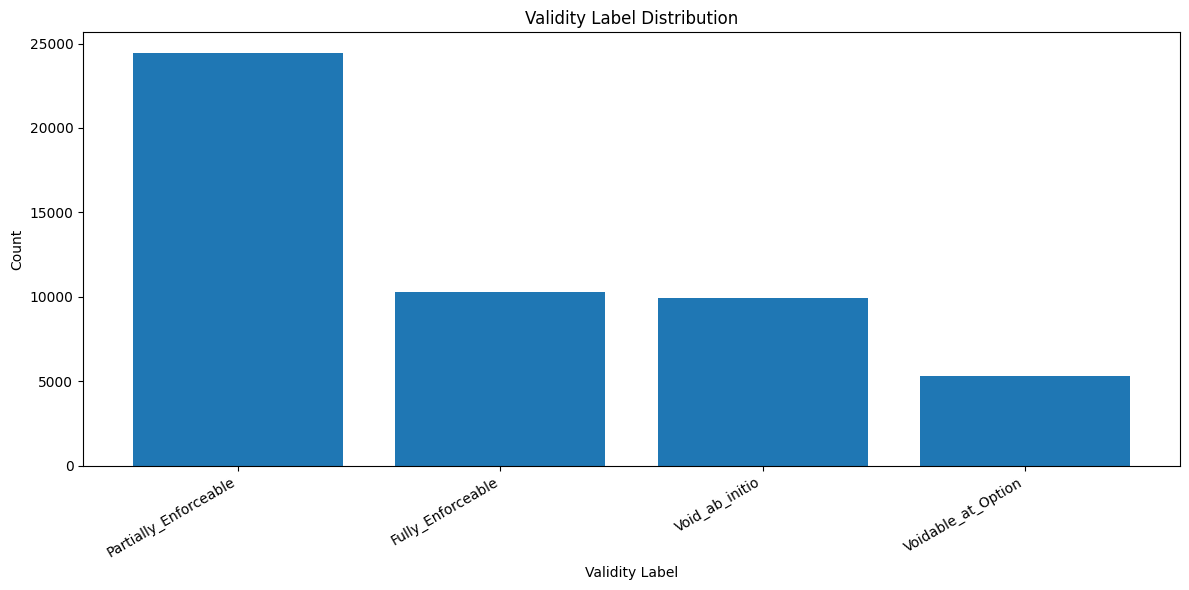

In [35]:
plt.figure(figsize=(12,6))

validity = df["validity_label"].value_counts()

plt.bar(
    validity.index,
    validity.values
)

plt.title("Validity Label Distribution")
plt.xlabel("Validity Label")
plt.ylabel("Count")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/validity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
import os

print(os.listdir(PLOTS_DIR))

['validity_distribution.png']


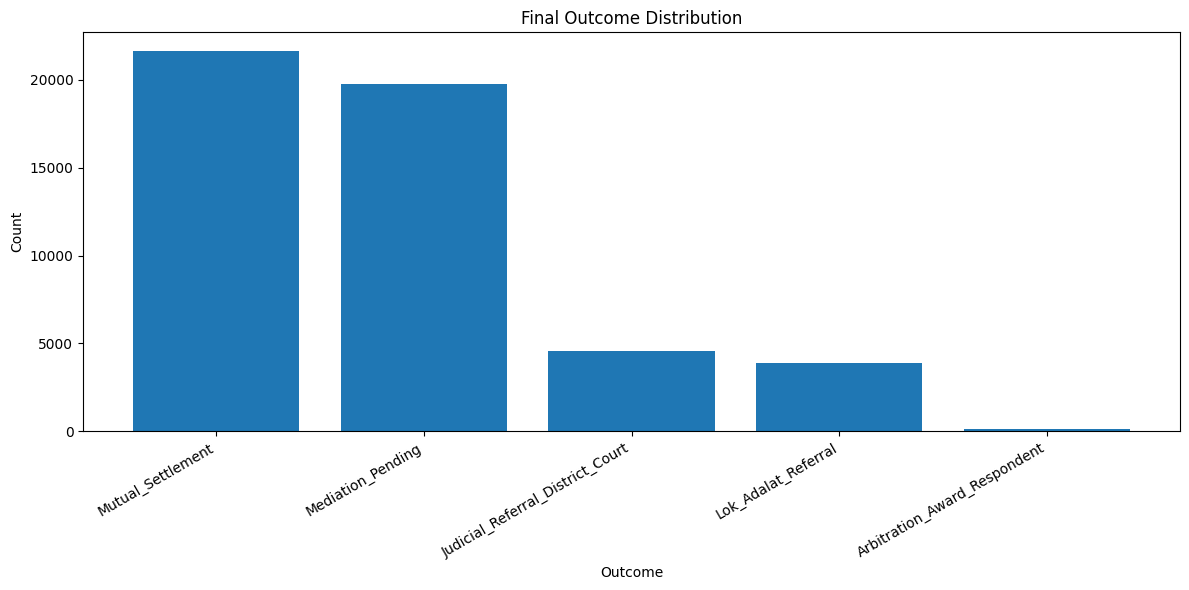

In [37]:
plt.figure(figsize=(12,6))

outcomes = df["final_outcome"].value_counts()

plt.bar(
    outcomes.index,
    outcomes.values
)

plt.title("Final Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/outcome_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

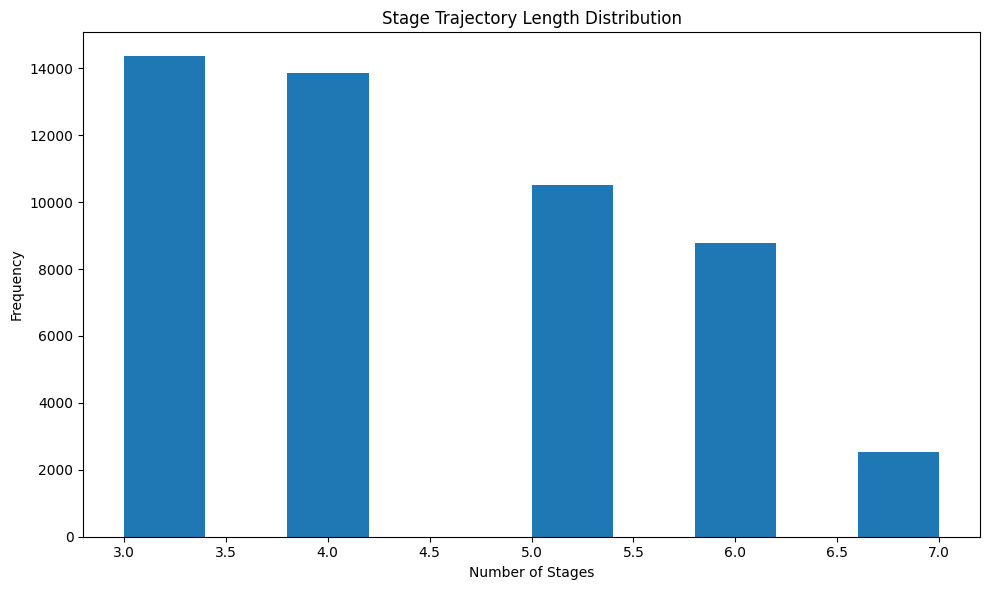

In [38]:
import json

stage_lengths = df["stage_trajectory"].apply(
    lambda x: len(json.loads(x))
)

plt.figure(figsize=(10,6))

plt.hist(
    stage_lengths,
    bins=10
)

plt.title("Stage Trajectory Length Distribution")
plt.xlabel("Number of Stages")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/stage_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

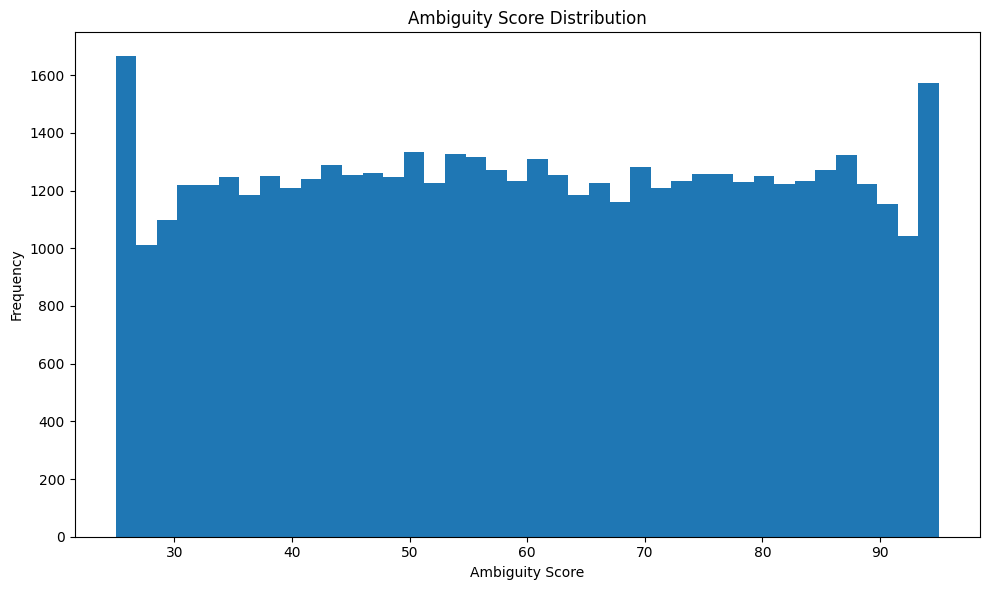

In [39]:
plt.figure(figsize=(10,6))

plt.hist(
    df["ambiguity_score"],
    bins=40
)

plt.title("Ambiguity Score Distribution")
plt.xlabel("Ambiguity Score")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/ambiguity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

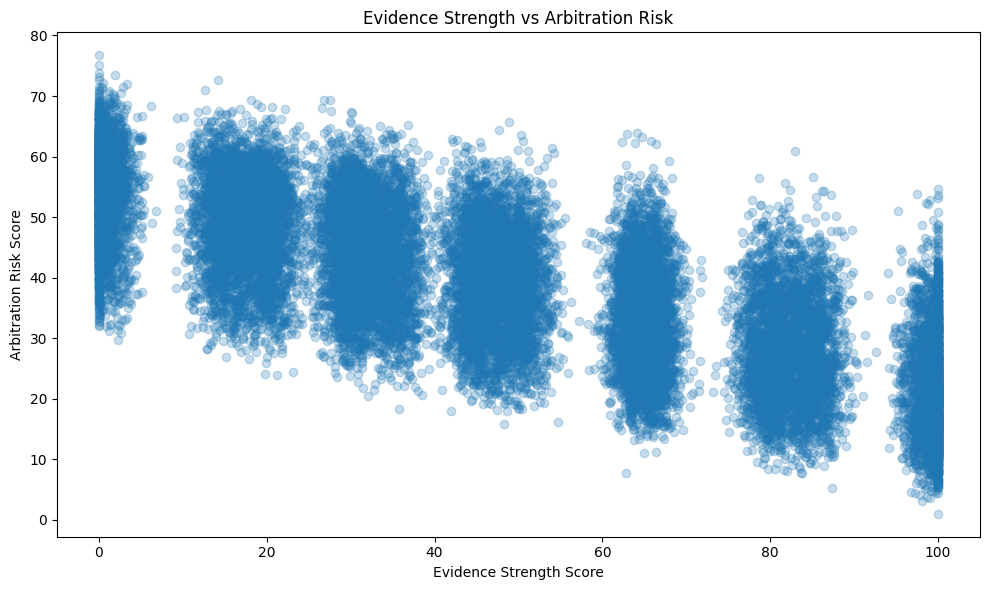

In [40]:
sample_df = df.sample(
    25000,
    random_state=42
)

plt.figure(figsize=(10,6))

plt.scatter(
    sample_df["evidence_strength_score"],
    sample_df["arbitration_risk_score"],
    alpha=0.25
)

plt.xlabel("Evidence Strength Score")
plt.ylabel("Arbitration Risk Score")

plt.title(
    "Evidence Strength vs Arbitration Risk"
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/evidence_vs_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

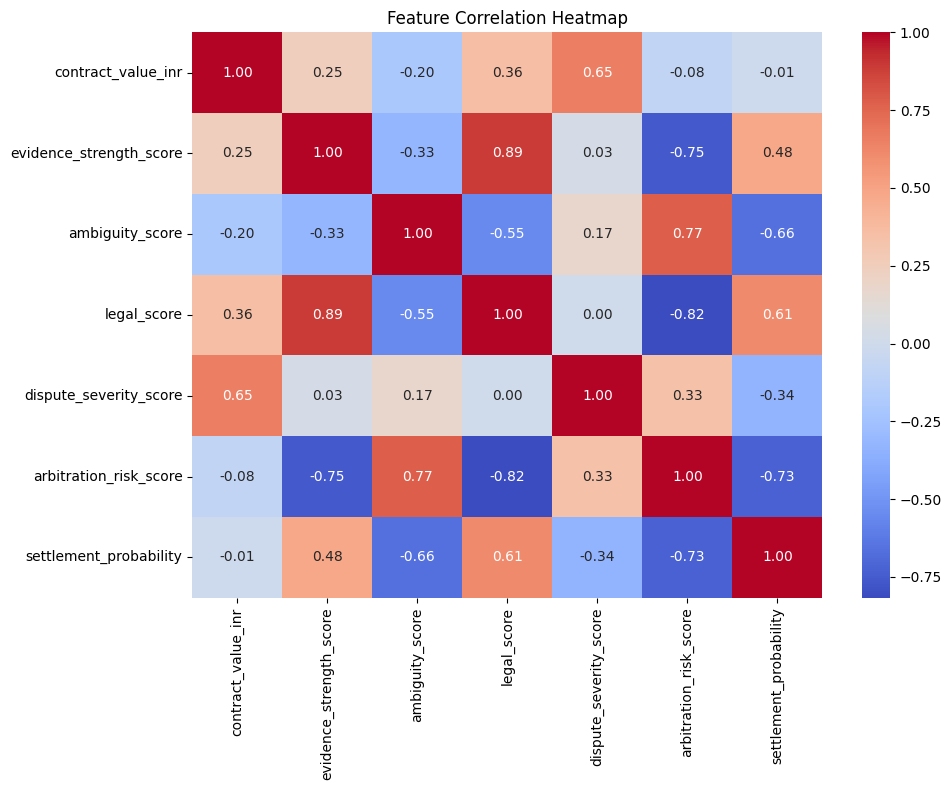

In [41]:
cols = [
    "contract_value_inr",
    "evidence_strength_score",
    "ambiguity_score",
    "legal_score",
    "dispute_severity_score",
    "arbitration_risk_score",
    "settlement_probability"
]

corr = df[cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

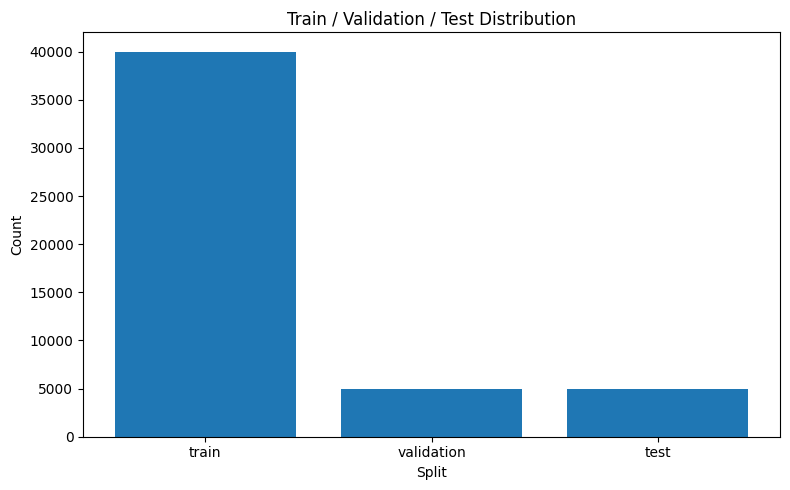

In [42]:
plt.figure(figsize=(8,5))

split_counts = df["split"].value_counts()

plt.bar(
    split_counts.index,
    split_counts.values
)

plt.title("Train / Validation / Test Distribution")
plt.xlabel("Split")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/split_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
import os

ROOT = "/content/HinglishContractFlow"

folders = [
    "Data",
    "Docs",
    "Plots",
    "Schema",
    "notebooks",
    "src"
]

for folder in folders:
    os.makedirs(
        os.path.join(ROOT, folder),
        exist_ok=True
    )

print("Repository structure created successfully.")

Repository structure created successfully.


In [44]:
import os

for root, dirs, files in os.walk("/content/HinglishContractFlow"):
    level = root.replace("/content/HinglishContractFlow", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

HinglishContractFlow/
    Docs/
    Schema/
    notebooks/
    Data/
    src/
    Plots/


In [45]:
import shutil
import os

PLOTS_DIR = "/content/hinglish_contract_flow/Plots"
TARGET_PLOTS = "/content/HinglishContractFlow/Plots"

for file in os.listdir(PLOTS_DIR):
    if file.endswith(".png"):
        shutil.copy(
            os.path.join(PLOTS_DIR, file),
            os.path.join(TARGET_PLOTS, file)
        )

print("Plots copied successfully.")
print(os.listdir(TARGET_PLOTS))

Plots copied successfully.
['ambiguity_distribution.png', 'outcome_distribution.png', 'split_distribution.png', 'correlation_heatmap.png', 'validity_distribution.png', 'stage_length_distribution.png', 'evidence_vs_risk.png']


In [46]:
import pandas as pd

stats = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Train Records",
        "Validation Records",
        "Test Records",
        "Total Features"
    ],
    "Value": [
        len(df),
        (df["split"]=="train").sum(),
        (df["split"]=="validation").sum(),
        (df["split"]=="test").sum(),
        len(df.columns)
    ]
})

stats.to_csv(
    "/content/HinglishContractFlow/Docs/dataset_statistics.csv",
    index=False
)

stats

,Metric,Value
0,Total Records,50000
1,Train Records,40000
2,Validation Records,5000
3,Test Records,5000
4,Total Features,59


In [47]:
schema_text = "\n".join(df.columns)

with open(
    "/content/HinglishContractFlow/Schema/columns.txt",
    "w"
) as f:
    f.write(schema_text)

print("Schema exported.")

Schema exported.


In [48]:
print(
    "Later download HinglishContractFlow.ipynb "
    "and upload into notebooks/ folder."
)

Later download HinglishContractFlow.ipynb and upload into notebooks/ folder.


In [49]:
import os

for root, dirs, files in os.walk("/content/HinglishContractFlow"):
    level = root.replace("/content/HinglishContractFlow", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    {file}")

HinglishContractFlow/
    LICENSE
    requirements.txt
    README.md
    Docs/
        dataset_summary.json
        dataset_statistics.csv
        DATA_DICTIONARY.md
        METHODOLOGY.md
        DATASET_CARD.md
    Schema/
        columns.txt
    notebooks/
        .gitkeep
    Data/
        README.md
        .gitkeep
    src/
        .gitkeep
    Plots/
        ambiguity_distribution.png
        outcome_distribution.png
        split_distribution.png
        correlation_heatmap.png
        validity_distribution.png
        stage_length_distribution.png
        evidence_vs_risk.png


In [50]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("States:", df["state"].nunique())
print("Dispute Types:", df["dispute_type"].nunique())
print("Statutes:", df["applicable_statute"].nunique())

Rows: 50000
Columns: 59
States: 5
Dispute Types: 6
Statutes: 59


In [51]:
print(df.columns.tolist())

['dispute_id', 'chunk_id', 'record_index', 'state', 'district_hub', 'dispute_type', 'applicable_statute', 'complainant_name', 'respondent_name', 'legal_institution', 'contract_start_date', 'dispute_filing_date', 'hearing_date', 'contract_duration_days', 'delay_days', 'dispute_age_days', 'limitation_risk_flag', 'monthly_rent_inr', 'contract_value_inr', 'security_deposit_inr', 'penalty_inr', 'claimed_damages_inr', 'land_area_acres', 'crop_yield_qtl', 'has_written_agreement', 'has_registered_deed', 'has_witness_testimony', 'legal_aid_utilized', 'evidence_strength_score', 'ambiguity_score', 'legal_score', 'dispute_severity_score', 'arbitration_risk_score', 'settlement_probability', 'linguistic_mix_ratio', 'num_code_switch_events', 'dialect_intensity_score', 'regional_dialect', 'initial_stage', 'final_stage', 'num_stage_transitions', 'stage_trajectory', 'validity_label', 'final_outcome', 'difficulty_tier', 'primary_ambiguous_clause', 'num_disputed_clauses', 'critic_finding', 'critic_confide

In [52]:
df["split"].value_counts()

,count
split,
train,40000
validation,5000
test,5000


In [53]:
import os

os.makedirs("/content/HinglishContractFlow/Data/train", exist_ok=True)
os.makedirs("/content/HinglishContractFlow/Data/validation", exist_ok=True)
os.makedirs("/content/HinglishContractFlow/Data/test", exist_ok=True)

print("Split folders created.")

Split folders created.


In [54]:
import glob
import pandas as pd

files = glob.glob("/content/hinglish_contract_flow/*.parquet")

for f in files[:3]:
    temp = pd.read_parquet(f, columns=["split"])
    print(temp["split"].value_counts())
    print("-"*50)

split
train         20000
validation     2500
test           2500
Name: count, dtype: int64
--------------------------------------------------
split
train         20000
validation     2500
test           2500
Name: count, dtype: int64
--------------------------------------------------


In [55]:
print(df["dispute_type"].unique())

['agricultural_lease' 'commercial_rental' 'logistics_partnership'
 'cold_storage' 'machinery_lease' 'water_sharing']


In [56]:
print(df["state"].unique())

['Maharashtra' 'Punjab' 'Uttar_Pradesh' 'Haryana' 'Rajasthan']


In [57]:
import os

total_size = 0

for f in files:
    total_size += os.path.getsize(f)

print(round(total_size/(1024**2),2), "MB")

29.82 MB


In [14]:
import json

summary = {
    "dataset_name": "HinglishContractFlow",
    "records": 1000000,
    "features": 59,
    "states": 5,
    "dispute_types": 6,
    "statutes": 59,
    "size_mb": 595.85,
    "train_records": 800000,
    "validation_records": 100000,
    "test_records": 100000,
    "states_list": [
        "Maharashtra",
        "Punjab",
        "Haryana",
        "Rajasthan",
        "Uttar_Pradesh"
    ],
    "dispute_categories": [
        "agricultural_lease",
        "commercial_rental",
        "cold_storage",
        "water_sharing",
        "machinery_lease",
        "logistics_partnership"
    ]
}

with open(
    "/content/HinglishContractFlow/Docs/dataset_summary.json",
    "w"
) as f:
    json.dump(summary, f, indent=4)

print("dataset_summary.json created")

dataset_summary.json created


In [11]:
DATASET_CARD = r"""
# DATASET CARD — HinglishContractFlow

## Dataset Identification

**Dataset Name:** HinglishContractFlow

**Dataset Type:** Large-Scale Synthetic Legal Benchmark

**Domain:** Legal AI, Contract Intelligence, Arbitration Analytics, Code-Mixed Language Understanding

**Primary Language:** Hinglish (Hindi-English Code-Mixed Legal Discourse)

**Storage Format:** Apache Parquet (Snappy Compression)

**Dataset Size:** 595.85 MB

**Total Records:** 1,000,000

**Total Features:** 59

**States Represented:** 5

**Dispute Categories:** 6

**Statutory Frameworks:** 59

---

# Executive Summary

HinglishContractFlow is a large-scale benchmark dataset designed to advance research in legal reasoning, dispute resolution, arbitration intelligence, multilingual natural language processing, contract analytics, and code-mixed language understanding.

The benchmark focuses on disputes emerging from India's informal and semi-formal economic sectors, where contractual communication frequently combines Hindi expressions, regional vernacular speech patterns, and English legal terminology.

Unlike traditional legal datasets that focus primarily on formal contracts or judicial opinions, HinglishContractFlow models complete dispute lifecycles, including contractual ambiguity, negotiation trajectories, evidentiary strength, enforceability assessment, arbitration risk, procedural progression, and dispute outcomes.

The benchmark is specifically designed to support the development of intelligent legal systems capable of reasoning within multilingual, code-mixed, and procedurally complex environments.

---

# Motivation

Modern Legal AI systems are typically trained on formal English legal corpora.

However, a substantial portion of legal communication in emerging economies occurs through:

* Informal contractual arrangements
* Vernacular negotiations
* Oral amendments
* Regional legal interpretations
* Code-mixed legal discourse

Existing benchmarks rarely model:

* Contract ambiguity propagation
* Negotiation dynamics
* Arbitration processes
* Mediation trajectories
* Procedural stage transitions
* Multilingual legal communication

HinglishContractFlow addresses these gaps through a large-scale benchmark that integrates legal reasoning, dispute progression, arbitration analytics, and code-mixed language understanding.

---

# Geographic Coverage

The benchmark models disputes across five major Indian jurisdictions:

| State         | Coverage Focus                                 |
| ------------- | ---------------------------------------------- |
| Maharashtra   | Agricultural leasing, logistics, cold storage  |
| Punjab        | Agricultural contracts and machinery leasing   |
| Haryana       | Land-use agreements and logistics partnerships |
| Rajasthan     | Water-sharing and commercial rentals           |
| Uttar Pradesh | Commercial leasing and contractual disputes    |

The selected jurisdictions provide linguistic diversity, procedural variation, and heterogeneous dispute structures.

---

# Dispute Categories

The benchmark includes six dispute categories.

## Agricultural Lease

Disputes involving:

* Agricultural tenancy
* Land-use restrictions
* Crop-sharing arrangements
* Yield-related disagreements

---

## Commercial Rental

Disputes involving:

* Commercial property leasing
* Security deposit conflicts
* Notice-period disagreements
* Early termination disputes

---

## Cold Storage

Disputes involving:

* Agricultural storage agreements
* Damage liability
* Capacity allocation
* Delayed release of stored goods

---

## Water Sharing

Disputes involving:

* Irrigation access
* Water allocation rights
* Seasonal resource sharing
* Distribution disagreements

---

## Machinery Lease

Disputes involving:

* Agricultural equipment leasing
* Maintenance responsibility
* Damage liability
* Equipment-return compliance

---

## Logistics Partnership

Disputes involving:

* Freight agreements
* Distribution partnerships
* Delivery obligations
* Cost-sharing arrangements

---

# Legal Framework Coverage

The benchmark incorporates 59 statutory frameworks and legal reference structures.

Each record contains:

* Jurisdictional context
* Applicable statutory references
* Contract validity assessments
* Legal critic evaluations

Legal reasoning components are grounded within the dispute-specific statutory context associated with each record.

---

# Dataset Composition

## Total Records

```text
1,000,000
```

## Total Features

```text
59
```

## Dataset Size

```text
595.85 MB
```

## Storage Format

```text
Apache Parquet
```

## Compression

```text
Snappy
```

## Number of Parquet Files

```text
40
```

## Average Records per Chunk

```text
25,000
```

---

# Dataset Splits

| Split      | Records | Percentage |
| ---------- | ------- | ---------- |
| Train      | 800,000 | 80%        |
| Validation | 100,000 | 10%        |
| Test       | 100,000 | 10%        |

Split assignments are stored directly within the `split` column.

This design enables:

* Single-file loading
* Distributed processing
* Flexible benchmark partitioning
* Reproducible evaluation pipelines
# Dataset Schema Overview

The benchmark contains 59 features grouped into multiple semantic blocks.

## Identity and Metadata

These fields uniquely identify disputes and dataset partitions.

* dispute_id
* chunk_id
* record_index

---

## Jurisdiction and Context

These fields provide regional and legal context.

* state
* district_hub
* dispute_type
* applicable_statute
* legal_institution

---

## Temporal Features

These fields model contractual and procedural timelines.

* contract_start_date
* dispute_filing_date
* hearing_date
* contract_duration_days
* delay_days
* dispute_age_days
* limitation_risk_flag

---

## Financial Features

These variables model contractual economics.

* monthly_rent_inr
* contract_value_inr
* security_deposit_inr
* penalty_inr
* claimed_damages_inr

---

## Agricultural Features

These fields model land and productivity characteristics.

* land_area_acres
* crop_yield_qtl

---

## Documentary Evidence Features

These variables capture evidentiary support.

* has_written_agreement
* has_registered_deed
* has_witness_testimony
* legal_aid_utilized

---

## Legal Assessment Features

These fields quantify dispute quality and enforceability.

* evidence_strength_score
* ambiguity_score
* legal_score
* dispute_severity_score
* arbitration_risk_score
* settlement_probability

---

## Linguistic Features

These variables capture code-mixing behavior.

* linguistic_mix_ratio
* num_code_switch_events
* dialect_intensity_score
* regional_dialect

---

## Procedural Features

These variables model dispute progression.

* initial_stage
* final_stage
* num_stage_transitions
* stage_trajectory

---

## Outcome Features

These variables represent dispute resolution outcomes.

* validity_label
* final_outcome
* difficulty_tier

---

## Explainability Features

These fields support interpretable legal reasoning.

* critic_finding
* critic_confidence

---

## Structured Trace Features

These fields contain rich procedural telemetry.

* negotiation_trace_json
* transaction_manifest_json

---

## Latent Variables

Internal latent variables used during generation.

* latent_economic_scale
* latent_legal_formality
* latent_dispute_intensity
* latent_ambiguity_level
* latent_settlement_proclivity

---

## Statistical Noise Features

Generation diagnostics.

* colored_noise_economic
* colored_noise_temporal

---

# Generation Methodology Summary

The benchmark is produced through a structured simulation pipeline designed to generate realistic legal disputes while preserving statistical diversity and procedural consistency.

Core components include:

### Correlated Feature Generation

Feature dependencies are introduced through correlation-aware sampling procedures.

This enables realistic relationships between:

* evidence strength
* legal quality
* ambiguity
* settlement probability
* arbitration risk

---

### Contract Simulation

Each record is instantiated through a synthetic contract generation framework that models:

* contractual value
* lease duration
* deposits
* penalties
* disputed damages

---

### Ambiguity Injection

Selected contractual clauses are deliberately assigned ambiguity levels.

Examples include:

* force majeure clauses
* escalation mechanisms
* payment schedules
* oral amendments
* termination conditions

---

### Procedural Simulation

Each dispute progresses through multiple procedural stages.

Example trajectory:

```text
Draft_Circulated
→ Clause_Negotiation
→ Counter_Offer_Filed
→ Mediation_Requested
→ Terminated
```

---

### Legal Critic Evaluation

Every dispute is processed through a legal critic framework that evaluates:

* enforceability
* evidentiary sufficiency
* statutory consistency
* procedural compliance

The resulting reasoning is stored within:

```text
critic_finding
```

---

### Outcome Assignment

Dispute outcomes are generated using structured legal and procedural signals.

Possible outcomes include:

* Mutual_Settlement
* Mediation_Pending
* Lok_Adalat_Referral
* Judicial_Referral_District_Court

Outcome generation is conditioned upon:

* evidence strength
* ambiguity
* legal score
* procedural trajectory

---

# Intended Research Applications

The benchmark supports a wide range of research tasks.

## Legal AI

* Legal reasoning
* Contract intelligence
* Statute retrieval
* Case assessment

---

## Natural Language Processing

* Code-mixed language understanding
* Legal text generation
* Explanation generation
* Dialogue modeling

---

## Predictive Analytics

* Outcome prediction
* Settlement forecasting
* Arbitration risk estimation
* Validity classification

---

## Agentic Systems

* Autonomous mediation
* Legal assistants
* Negotiation agents
* Multi-agent dispute resolution

# Ethical Considerations

HinglishContractFlow is a synthetic benchmark intended exclusively for research, benchmarking, and educational purposes.

The dataset does not contain:

* Real litigants
* Real contracts
* Real court proceedings
* Personally identifiable information
* Sensitive legal records

Although statutory references and procedural structures are modeled to resemble realistic legal environments, the dataset should not be interpreted as legal authority.

Users should not deploy models trained on this dataset as substitutes for professional legal advice.

---

# Known Limitations

Several limitations should be considered when interpreting benchmark results.

## Synthetic Generation

The dataset is procedurally generated and therefore may not capture all nuances of real-world legal disputes.

---

## Geographic Scope

The benchmark currently models five Indian states.

Future releases may expand jurisdictional coverage.

---

## Procedural Simplification

Certain legal procedures are abstracted to maintain tractable simulation complexity.

---

## Limited Dispute Categories

Only six dispute categories are currently represented.

Many important legal domains remain outside scope.

Examples include:

* Criminal law
* Constitutional law
* Intellectual property
* Taxation
* Labor disputes

---

## No Judicial Authority

The benchmark is not intended to model actual judicial decision making.

It should not be used for legal decision support.

---

# Validation Summary

The benchmark generation pipeline includes automated validation procedures.

## Dataset Integrity Checks

* Record count verification
* Schema compliance validation
* Null-value inspection
* Data-type consistency checks

---

## Statistical Validation

Validation includes:

* Distribution consistency
* Correlation inspection
* Score-range verification
* Split-balance validation

---

## Procedural Validation

Checks include:

* Stage trajectory integrity
* Outcome consistency
* Validity label verification
* Negotiation trace completeness

---

## Split Validation

The following split distribution is verified:

| Split      | Records |
| ---------- | ------- |
| Train      | 800,000 |
| Validation | 100,000 |
| Test       | 100,000 |

---

# Related Documentation

The following documents provide additional details.

| Document           | Purpose                                               |
| ------------------ | ----------------------------------------------------- |
| DATA_DICTIONARY.md | Complete feature-level schema documentation           |
| METHODOLOGY.md     | Detailed generation pipeline and modeling assumptions |
| BENCHMARK_TASKS.md | Benchmark tasks and evaluation settings               |
| README.md          | Repository overview and usage instructions            |

---

# Citation

```bibtex
@dataset{hinglishcontractflow2026,
  title={HinglishContractFlow: A Large-Scale Benchmark for Vernacular Contract Intelligence, Dispute Resolution, and Code-Mixed Legal Reasoning},
  year={2026}
}
```

---

# License

Released for research, benchmarking, and educational purposes.

Users are encouraged to cite the benchmark when reporting experimental results.

Refer to the repository LICENSE file for usage terms.

---

# Contact

For benchmark-related questions, issues, or improvements, please use the repository issue tracker and accompanying documentation.

---

End of Dataset Card.


"""

In [15]:
with open(
    "/content/HinglishContractFlow/Docs/DATASET_CARD.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(DATASET_CARD)

print("DATASET_CARD.md created successfully")

DATASET_CARD.md created successfully


In [16]:
import os

print(
    os.path.exists(
        "/content/HinglishContractFlow/Docs/DATASET_CARD.md"
    )
)

True


In [45]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. dispute_id
2. chunk_id
3. record_index
4. state
5. district_hub
6. dispute_type
7. applicable_statute
8. complainant_name
9. respondent_name
10. legal_institution
11. contract_start_date
12. dispute_filing_date
13. hearing_date
14. contract_duration_days
15. delay_days
16. dispute_age_days
17. limitation_risk_flag
18. monthly_rent_inr
19. contract_value_inr
20. security_deposit_inr
21. penalty_inr
22. claimed_damages_inr
23. land_area_acres
24. crop_yield_qtl
25. has_written_agreement
26. has_registered_deed
27. has_witness_testimony
28. legal_aid_utilized
29. evidence_strength_score
30. ambiguity_score
31. legal_score
32. dispute_severity_score
33. arbitration_risk_score
34. settlement_probability
35. linguistic_mix_ratio
36. num_code_switch_events
37. dialect_intensity_score
38. regional_dialect
39. initial_stage
40. final_stage
41. num_stage_transitions
42. stage_trajectory
43. validity_label
44. final_outcome
45. difficulty_tier
46. primary_ambiguous_clause
47. num_disputed_clau

In [9]:
DATA_DICTIONARY = r"""
# DATA DICTIONARY — HinglishContractFlow

## Overview

This document provides a complete schema reference for HinglishContractFlow.

The benchmark contains 59 features spanning identity, jurisdiction, finance, legal reasoning, procedural progression, linguistic behavior, dispute outcomes, and latent simulation variables.

---

# Feature Reference

| #  | Column                 | Type        | Description                                               |
| -- | ---------------------- | ----------- | --------------------------------------------------------- |
| 1  | dispute_id             | string      | Unique identifier assigned to each dispute record         |
| 2  | chunk_id               | integer     | Generation chunk identifier used during parquet streaming |
| 3  | record_index           | integer     | Record index within generation sequence                   |
| 4  | state                  | categorical | State jurisdiction associated with the dispute            |
| 5  | district_hub           | categorical | Regional district or operational hub                      |
| 6  | dispute_type           | categorical | Dispute category associated with the contractual conflict |
| 7  | applicable_statute     | string      | Statutory framework governing the dispute                 |
| 8  | complainant_name       | string      | Synthetic complainant identifier                          |
| 9  | respondent_name        | string      | Synthetic respondent identifier                           |
| 10 | legal_institution      | categorical | Legal body or dispute-resolution institution              |
| 11 | contract_start_date    | date        | Contract commencement date                                |
| 12 | dispute_filing_date    | date        | Date on which dispute was formally initiated              |
| 13 | hearing_date           | date        | Scheduled hearing or mediation date                       |
| 14 | contract_duration_days | integer     | Duration of contract in days                              |
| 15 | delay_days             | integer     | Delay observed relative to contractual expectations       |
| 16 | dispute_age_days       | integer     | Age of dispute in days                                    |
| 17 | limitation_risk_flag   | binary      | Indicates potential statutory limitation concerns         |
| 18 | monthly_rent_inr       | numeric     | Monthly contractual payment amount in Indian Rupees       |
| 19 | contract_value_inr     | numeric     | Total estimated contract value                            |
| 20 | security_deposit_inr   | numeric     | Security deposit associated with the agreement            |

---

# Feature Notes (1–20)

### Identity Features

Columns 1–3 provide unique identification and generation metadata.

These variables support:

* Record traceability
* Chunk-level processing
* Distributed storage

---

### Jurisdiction Features

Columns 4–7 define the legal and geographic context.

These variables are critical for:

* Statute retrieval
* Jurisdiction-aware reasoning
* Regional legal analysis

---

### Participant Features

Columns 8–9 represent synthetic legal actors.

These fields do not correspond to real individuals.

---

### Procedural Context

Column 10 specifies the institutional context under which the dispute proceeds.

Examples include:

* Mediation bodies
* Arbitration forums
* Local dispute-resolution institutions

---

### Temporal Features

Columns 11–17 model dispute timing and procedural progression.

These variables support:

* Delay analysis
* Limitation risk modeling
* Temporal forecasting

---

### Financial Features

Columns 18–20 capture core economic characteristics of the contract.

These variables frequently influence:

* Legal validity
* Settlement probability
* Arbitration risk
* Claimed damages
| #  | Column                  | Type        | Description                                                    |
| -- | ----------------------- | ----------- | -------------------------------------------------------------- |
| 21 | penalty_inr             | numeric     | Contractual penalty amount applicable under dispute conditions |
| 22 | claimed_damages_inr     | numeric     | Monetary damages claimed by the complainant                    |
| 23 | land_area_acres         | numeric     | Agricultural land area associated with the dispute             |
| 24 | crop_yield_qtl          | numeric     | Crop yield estimate in quintals                                |
| 25 | has_written_agreement   | binary      | Indicates presence of a written agreement                      |
| 26 | has_registered_deed     | binary      | Indicates whether the agreement was formally registered        |
| 27 | has_witness_testimony   | binary      | Indicates witness support for claims                           |
| 28 | legal_aid_utilized      | binary      | Indicates use of legal aid services                            |
| 29 | evidence_strength_score | numeric     | Quantifies evidentiary strength supporting claims              |
| 30 | ambiguity_score         | numeric     | Measures contractual ambiguity level                           |
| 31 | legal_score             | numeric     | Aggregate legal quality and enforceability score               |
| 32 | dispute_severity_score  | numeric     | Measures overall severity of dispute                           |
| 33 | arbitration_risk_score  | numeric     | Estimated risk of escalation to arbitration or litigation      |
| 34 | settlement_probability  | numeric     | Estimated likelihood of settlement                             |
| 35 | linguistic_mix_ratio    | numeric     | Degree of Hinglish code-mixing present in discourse            |
| 36 | num_code_switch_events  | integer     | Number of code-switching events detected                       |
| 37 | dialect_intensity_score | numeric     | Strength of regional dialect influence                         |
| 38 | regional_dialect        | categorical | Dominant regional dialect category                             |
| 39 | initial_stage           | categorical | Initial procedural stage of dispute                            |
| 40 | final_stage             | categorical | Final procedural stage reached by dispute                      |

---

# Feature Notes (21–40)

### Financial Escalation Features

Columns 21–22 quantify monetary consequences arising from contractual disagreements.

These variables are important for:

* Damages estimation
* Outcome prediction
* Settlement forecasting

---

### Agricultural Context Features

Columns 23–24 provide domain-specific information for agricultural disputes.

These features support:

* Land-use analysis
* Productivity assessment
* Resource conflict modeling

---

### Documentary Evidence Features

Columns 25–28 capture legal documentation quality.

Higher documentary support generally correlates with:

* Stronger legal positions
* Lower ambiguity
* Higher enforceability

---

### Legal Assessment Features

Columns 29–34 represent core benchmark scoring variables.

These variables are among the most important features in the dataset.

Examples:

* evidence_strength_score
* ambiguity_score
* legal_score
* arbitration_risk_score

These scores support predictive legal intelligence research.

---

### Linguistic Features

Columns 35–38 model code-mixed legal discourse.

They capture:

* Hinglish intensity
* Dialect variation
* Code-switching behavior
* Regional language influence

These variables are particularly valuable for multilingual NLP research.

---

### Procedural Stage Features

Columns 39–40 describe dispute lifecycle progression.

Examples:

* Draft_Circulated
* Clause_Negotiation
* Counter_Offer_Filed
* Mediation_Requested
* Arbitration_Proceeding
* Terminated

These features support procedural trajectory modeling and sequential prediction tasks.
| #  | Column                       | Type          | Description                                             |
| -- | ---------------------------- | ------------- | ------------------------------------------------------- |
| 41 | num_stage_transitions        | integer       | Total number of procedural stage transitions            |
| 42 | stage_trajectory             | JSON / string | Complete procedural stage sequence                      |
| 43 | validity_label               | categorical   | Legal validity classification of the contract           |
| 44 | final_outcome                | categorical   | Final dispute resolution outcome                        |
| 45 | difficulty_tier              | categorical   | Difficulty level assigned to the dispute                |
| 46 | primary_ambiguous_clause     | categorical   | Principal clause responsible for ambiguity              |
| 47 | num_disputed_clauses         | integer       | Number of clauses under dispute                         |
| 48 | critic_finding               | text          | Legal critic explanation and reasoning                  |
| 49 | critic_confidence            | numeric       | Confidence score associated with critic reasoning       |
| 50 | negotiation_trace_json       | JSON          | Multi-turn negotiation conversation trace               |
| 51 | transaction_manifest_json    | JSON          | Structured transaction and dispute metadata             |
| 52 | latent_economic_scale        | numeric       | Internal latent economic factor                         |
| 53 | latent_legal_formality       | numeric       | Internal latent legal-formality factor                  |
| 54 | latent_dispute_intensity     | numeric       | Internal latent dispute-intensity factor                |
| 55 | latent_ambiguity_level       | numeric       | Internal latent ambiguity factor                        |
| 56 | latent_settlement_proclivity | numeric       | Internal latent settlement tendency factor              |
| 57 | split                        | categorical   | Dataset partition assignment (train/validation/test)    |
| 58 | colored_noise_economic       | numeric       | Economic colored-noise component used during generation |
| 59 | colored_noise_temporal       | numeric       | Temporal colored-noise component used during generation |

---

# Feature Notes (41–59)

### Procedural Telemetry

Columns 41–42 capture procedural evolution.

These variables enable:

* Trajectory prediction
* Sequential modeling
* Legal process simulation
* Markov-state analysis

---

### Outcome Features

Columns 43–45 represent benchmark targets.

Common tasks include:

* Validity prediction
* Outcome prediction
* Difficulty classification

---

### Ambiguity Features

Columns 46–47 describe contractual uncertainty.

These variables support:

* Ambiguity analysis
* Clause-level reasoning
* Contract risk assessment

---

### Explainability Features

Columns 48–49 provide interpretable legal reasoning.

The critic framework generates:

* Legal findings
* Statutory observations
* Enforceability explanations

These fields are particularly useful for explainable AI research.

---

### Negotiation Trace Features

Columns 50–51 contain the richest information in the benchmark.

These fields capture:

* Multi-turn interactions
* Dispute trajectories
* Structured mediation records
* Procedural telemetry

These variables are suitable for:

* LLM training
* Legal dialogue modeling
* Agentic mediation systems
* Multi-agent simulation

---

### Latent Variables

Columns 52–56 represent hidden simulation factors.

These variables are included primarily for:

* Benchmark analysis
* Controlled experimentation
* Research reproducibility

---

### Dataset Partition Feature

Column 57 defines benchmark splits.

Possible values:

* train
* validation
* test

---

### Generation Diagnostics

Columns 58–59 contain colored-noise signals used during synthetic generation.

These variables support:

* Generation auditing
* Statistical validation
* Reproducibility studies

---

# Recommended Prediction Targets

The following columns are recommended benchmark targets:

| Task                         | Target Column            |
| ---------------------------- | ------------------------ |
| Contract Validity Prediction | validity_label           |
| Outcome Prediction           | final_outcome            |
| Arbitration Risk Regression  | arbitration_risk_score   |
| Settlement Prediction        | settlement_probability   |
| Difficulty Classification    | difficulty_tier          |
| Clause Ambiguity Analysis    | primary_ambiguous_clause |

---

# Data Types Summary

| Type        | Approximate Count |
| ----------- | ----------------- |
| Numeric     | 25+               |
| Integer     | 10+               |
| Binary      | 5+                |
| Categorical | 10+               |
| Text        | 2                 |
| JSON        | 2                 |

---

End of Data Dictionary.
"""


In [12]:
with open(
    "/content/HinglishContractFlow/Docs/DATA_DICTIONARY.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(DATA_DICTIONARY)

print("DATA_DICTIONARY.md created successfully")

DATA_DICTIONARY.md created successfully


In [13]:
import os

print(
    os.path.exists(
        "/content/HinglishContractFlow/Docs/DATA_DICTIONARY.md"
    )
)

True


In [17]:
!ls /content/HinglishContractFlow/Docs

DATA_DICTIONARY.md  DATASET_CARD.md  dataset_summary.json  METHODOLOGY.md


In [10]:
METHODOLOGY = r"""
# METHODOLOGY — HinglishContractFlow

## Overview

This document describes the design principles, generation framework, statistical modeling assumptions, procedural simulation mechanisms, and validation methodology used to construct the HinglishContractFlow benchmark.

The objective of HinglishContractFlow is to provide a large-scale benchmark for legal reasoning, arbitration analytics, contract intelligence, dispute progression modeling, and code-mixed language understanding within vernacular legal environments.

The benchmark is designed to balance:

* Statistical realism
* Legal plausibility
* Procedural consistency
* Linguistic diversity
* Reproducibility

while remaining computationally feasible to generate and distribute at scale.

---

# Benchmark Design Philosophy

HinglishContractFlow was developed around five primary design objectives.

## 1. Legal Realism

The benchmark should capture realistic legal dispute characteristics including:

* contractual obligations
* ambiguity propagation
* evidentiary variation
* procedural progression
* dispute resolution outcomes

without relying on real legal records.

---

## 2. Procedural Modeling

Most legal datasets contain static legal text.

HinglishContractFlow models disputes as evolving processes.

Each dispute progresses through multiple procedural stages, enabling research into:

* outcome forecasting
* mediation systems
* procedural reasoning
* agentic legal workflows

---

## 3. Code-Mixed Legal Communication

Real-world legal communication frequently contains mixtures of:

* Hindi
* English
* regional vernacular expressions
* legal terminology

The benchmark incorporates linguistic mixture characteristics through structured code-switching features and negotiation traces.

---

## 4. Explainability

Every dispute contains:

* critic findings
* critic confidence estimates
* validity assessments
* outcome labels

to support interpretable legal reasoning research.

---

## 5. Scalability

The benchmark generation pipeline is designed to support:

* streaming generation
* chunked storage
* large-scale experimentation

while maintaining modest memory requirements.

---

# Dataset Generation Pipeline

The benchmark generation process consists of several stages.

```text
Jurisdiction Selection
        ↓
Contract Generation
        ↓
Correlated Feature Sampling
        ↓
Ambiguity Injection
        ↓
Procedural Simulation
        ↓
Legal Critic Evaluation
        ↓
Outcome Assignment
        ↓
Negotiation Trace Generation
        ↓
Validation
        ↓
Parquet Export
```

Each generated record passes through all stages before inclusion in the benchmark.

---

# Jurisdiction Modeling

Disputes are sampled across five Indian jurisdictions.

* Maharashtra
* Punjab
* Haryana
* Rajasthan
* Uttar Pradesh

Jurisdiction determines:

* statutory context
* dialect variation
* dispute distributions
* institutional characteristics

Jurisdictional conditioning introduces diversity while preserving internal consistency.

---

# Dispute Category Modeling

Six dispute categories are modeled.

| Category              | Example Themes            |
| --------------------- | ------------------------- |
| agricultural_lease    | land use, crop sharing    |
| commercial_rental     | tenancy and deposits      |
| cold_storage          | storage liability         |
| water_sharing         | irrigation allocation     |
| machinery_lease       | equipment leasing         |
| logistics_partnership | transportation agreements |

Each category influences:

* financial distributions
* ambiguity patterns
* procedural complexity
* outcome probabilities

---

# Contract Generation

Each dispute begins with synthetic contract construction.

Generated variables include:

* contract value
* lease duration
* deposits
* penalties
* damages
* land characteristics

These variables establish the economic foundation of the dispute.

Contract parameters are sampled from bounded domain-specific distributions rather than uniform random ranges.

---

# Correlated Feature Modeling

Independent random sampling often produces unrealistic datasets.

To avoid this limitation, HinglishContractFlow incorporates correlated feature generation.

Key variables are generated with dependency structures that preserve realistic relationships among:

* legal quality
* evidentiary strength
* ambiguity
* dispute severity
* settlement likelihood

This produces more coherent dispute profiles than independent sampling approaches.

---

# Statistical Dependency Modeling

Feature dependencies influence downstream variables.

Examples include:

* stronger evidence increasing legal scores
* higher ambiguity increasing arbitration risk
* greater dispute severity reducing settlement probability
* stronger documentation improving enforceability

These relationships improve benchmark realism and support meaningful predictive tasks.
# Colored Noise Injection

Purely random synthetic datasets often exhibit unrealistically smooth distributions.

To introduce realistic variability, HinglishContractFlow incorporates colored-noise processes during generation.

Two diagnostic variables are retained:

* colored_noise_economic
* colored_noise_temporal

These signals introduce controlled variation into:

* economic features
* temporal characteristics
* dispute progression dynamics

The objective is to emulate real-world fluctuations while preserving overall distributional stability.

---

# Ambiguity Injection Framework

Contract ambiguity is a central component of legal disputes.

The benchmark explicitly models ambiguity through:

* payment schedules
* force majeure clauses
* termination conditions
* oral amendments
* escalation mechanisms

Each dispute receives:

* ambiguity_score
* primary_ambiguous_clause
* num_disputed_clauses

These variables enable ambiguity-aware legal reasoning research.

---

# Procedural Stage Simulation

Disputes evolve through procedural stages rather than remaining static records.

Each dispute is represented as a procedural trajectory.

Typical stages include:

* Draft_Circulated
* Clause_Negotiation
* Counter_Offer_Filed
* Mediation_Requested
* Arbitration_Proceeding
* Terminated

The resulting sequence is stored within:

```text
stage_trajectory
```

Additional procedural features include:

* initial_stage
* final_stage
* num_stage_transitions

---

# Stage Transition Modeling

Stage progression is governed by structured transition logic.

The objective is to ensure:

* plausible dispute evolution
* realistic stage frequencies
* diverse procedural paths

rather than generating identical workflows.

This design enables research into:

* procedural prediction
* legal process forecasting
* sequential decision systems

---

# Legal Critic Framework

A legal critic component evaluates each generated dispute.

The critic produces:

* enforceability assessment
* evidentiary observations
* statutory consistency checks
* procedural findings

Outputs are stored in:

```text
critic_finding
```

and accompanied by:

```text
critic_confidence
```

The critic is intended to provide explainable reasoning signals for downstream research.

---

# Validity Assessment

Each dispute receives a legal validity classification.

Possible labels include:

* Fully_Enforceable
* Partially_Enforceable
* Voidable_at_Option
* Void_ab_initio

Validity assignments depend on:

* documentation quality
* ambiguity
* evidentiary strength
* legal score

These labels serve as benchmark targets for legal classification tasks.

---

# Outcome Generation

Dispute outcomes are assigned using structured legal and procedural signals.

Potential outcomes include:

* Mutual_Settlement
* Mediation_Pending
* Lok_Adalat_Referral
* Judicial_Referral_District_Court

Outcome assignment is influenced by:

* evidence strength
* legal score
* ambiguity
* procedural trajectory
* settlement probability

This approach generates diverse dispute-resolution pathways.

---

# Settlement Probability Modeling

The benchmark estimates settlement likelihood through:

```text
settlement_probability
```

This variable captures the tendency of disputes to resolve without escalation.

Factors influencing settlement propensity include:

* ambiguity
* dispute severity
* evidentiary strength
* legal quality

Settlement modeling supports predictive analytics and mediation research.

---

# Arbitration Risk Modeling

Each dispute contains:

```text
arbitration_risk_score
```

This score estimates escalation risk.

Higher values generally indicate:

* greater procedural complexity
* stronger disagreement
* lower likelihood of early settlement

The variable is intended for:

* regression benchmarks
* risk forecasting
* legal intelligence systems

---

# Negotiation Trace Synthesis

One of the most distinctive components of HinglishContractFlow is the generation of structured negotiation traces.

Each trace models:

* complaints
* responses
* counterarguments
* escalation attempts
* settlement discussions

The resulting conversations are stored within:

```text
negotiation_trace_json
```

These traces support:

* dialogue modeling
* legal conversational agents
* mediation assistants
* code-mixed reasoning systems

---

# Linguistic Modeling

The benchmark incorporates explicit linguistic diversity.

Relevant variables include:

* linguistic_mix_ratio
* num_code_switch_events
* dialect_intensity_score
* regional_dialect

These features enable evaluation of multilingual and code-mixed legal AI systems.

---

# Latent Variable Framework

Several latent variables are retained for research transparency.

These include:

* latent_economic_scale
* latent_legal_formality
* latent_dispute_intensity
* latent_ambiguity_level
* latent_settlement_proclivity

These factors represent internal simulation dimensions that influence observable outcomes.
# Validation Framework

Multiple validation procedures are applied before records are exported.

The objective is to ensure:

* schema consistency
* statistical coherence
* procedural integrity
* benchmark reproducibility

---

## Dataset Integrity Checks

The following checks are performed:

* Record count verification
* Schema validation
* Missing value inspection
* Data-type validation
* Export consistency verification

These checks ensure that generated records conform to the expected schema.

---

## Statistical Validation

The benchmark undergoes statistical inspection to verify:

* score distributions
* class distributions
* split balance
* feature ranges
* procedural diversity

Examples include:

* validity label distribution
* outcome distribution
* ambiguity distribution
* stage-length distribution

---

## Procedural Validation

Procedural validation verifies:

* valid stage sequences
* trajectory consistency
* outcome compatibility
* transition counts

This reduces the likelihood of impossible procedural paths.

---

## Split Validation

The benchmark uses a fixed split strategy.

| Split      | Records | Percentage |
| ---------- | ------- | ---------- |
| Train      | 800,000 | 80%        |
| Validation | 100,000 | 10%        |
| Test       | 100,000 | 10%        |

Split assignments are stored directly within the dataset.

This design improves reproducibility across experiments.

---

# Quality Assurance

The generation pipeline includes quality-control procedures designed to detect:

* invalid records
* schema violations
* unrealistic values
* procedural inconsistencies

Quality assurance is applied before parquet export.

---

# Reproducibility

The benchmark is designed to support reproducible experimentation.

Key reproducibility mechanisms include:

* deterministic generation controls
* chunk-based export
* documented schema
* fixed benchmark splits

Supporting files include:

* DATA_DICTIONARY.md
* DATASET_CARD.md
* BENCHMARK_TASKS.md

---

# Computational Characteristics

Generation was performed through chunked processing.

Benchmark characteristics:

| Metric           | Value     |
| ---------------- | --------- |
| Records          | 1,000,000 |
| Features         | 59        |
| Parquet Files    | 40        |
| Approximate Size | 595.85 MB |

Chunked generation enables efficient memory usage and scalable dataset construction.

---

# Limitations

Several limitations should be considered.

## Synthetic Generation

The benchmark does not contain real disputes.

Although designed for realism, generated records cannot capture every nuance of actual legal proceedings.

---

## Jurisdictional Scope

Only five states are currently modeled.

Future extensions may incorporate additional jurisdictions.

---

## Dispute Coverage

Only six dispute categories are represented.

Additional legal domains remain outside the benchmark scope.

---

## Procedural Simplification

Certain legal procedures are intentionally abstracted.

The benchmark prioritizes scalability and reproducibility over exhaustive procedural detail.

---

# Future Directions

Potential future extensions include:

* additional jurisdictions
* additional dispute categories
* richer negotiation traces
* multilingual expansion
* court-level procedural simulation
* retrieval-augmented legal benchmarks

---

# Related Documentation

| Document           | Purpose                                    |
| ------------------ | ------------------------------------------ |
| DATASET_CARD.md    | Dataset overview and intended uses         |
| DATA_DICTIONARY.md | Feature-level schema reference             |
| BENCHMARK_TASKS.md | Benchmark tasks and evaluation settings    |
| README.md          | Repository overview and usage instructions |

---

# Citation

```bibtex
@dataset{hinglishcontractflow2026,
  title={HinglishContractFlow: A Large-Scale Benchmark for Vernacular Contract Intelligence, Dispute Resolution, and Code-Mixed Legal Reasoning},
  year={2026}
}
```

---

End of Methodology Document.
"""

with open(
    "/content/HinglishContractFlow/Docs/METHODOLOGY.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(METHODOLOGY)

print("METHODOLOGY.md created successfully")

METHODOLOGY.md created successfully


In [54]:
import os

print(
    os.path.exists(
        "/content/HinglishContractFlow/Docs/METHODOLOGY.md"
    )
)

True


In [19]:
!ls /content/HinglishContractFlow/Plots

In [6]:
LICENSE_TEXT = """
MIT License

Copyright (c) 2026 Akhil Biradar

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND.
"""

with open(
    "/content/HinglishContractFlow/LICENSE",
    "w",
    encoding="utf-8"
) as f:
    f.write(LICENSE_TEXT)

print("LICENSE created")

LICENSE created


In [7]:
REQS = """
pandas
numpy
pyarrow
matplotlib
seaborn
scipy
tqdm
"""

with open(
    "/content/HinglishContractFlow/requirements.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(REQS)

print("requirements.txt created")

requirements.txt created


In [20]:
README = r"""
<div align="center">

# HinglishContractFlow

### Large-Scale Benchmark for Contract Intelligence, Arbitration Analytics, and Code-Mixed Legal Reasoning

<br>

![Records](https://img.shields.io/badge/Records-1,000,000-brightgreen)
![Features](https://img.shields.io/badge/Features-59-blue)
![States](https://img.shields.io/badge/States-5-orange)
![Dispute Types](https://img.shields.io/badge/Dispute_Types-6-purple)
![Statutes](https://img.shields.io/badge/Statutes-59-red)
![Language](https://img.shields.io/badge/Language-Hinglish-gold)
![Domain](https://img.shields.io/badge/Domain-Legal_AI-darkred)
![Format](https://img.shields.io/badge/Format-Apache_Parquet-lightgrey)
![License](https://img.shields.io/badge/License-MIT-success)

</div>

---

## Overview

HinglishContractFlow is a large-scale benchmark dataset designed for legal AI, contract intelligence, dispute resolution modeling, arbitration analytics, and multilingual legal reasoning.

The benchmark captures contractual disputes emerging from India's informal and semi-formal economic sectors, where legal communication frequently combines:

* English legal terminology
* Hindi conversational language
* Regional vernacular expressions
* Informal negotiation practices

Unlike conventional legal datasets that focus on formal contracts or judicial decisions, HinglishContractFlow models complete dispute lifecycles, enabling research into procedural reasoning, negotiation dynamics, legal validity assessment, settlement behavior, and code-mixed legal understanding.

---

## Why HinglishContractFlow?

Modern legal benchmarks largely focus on:

* Formal English contracts
* Judicial opinions
* Court judgments
* Statutory interpretation

However, a substantial portion of real-world contractual communication occurs in multilingual and code-mixed environments where agreements are negotiated, modified, and disputed through informal legal discourse.

HinglishContractFlow addresses this gap by introducing a benchmark specifically designed for:

### Contract Intelligence

Model contractual obligations, ambiguity, enforceability, and dispute risk.

### Arbitration Analytics

Study escalation behavior, mediation outcomes, and dispute-resolution pathways.

### Procedural Reasoning

Model disputes as evolving processes rather than isolated legal documents.

### Code-Mixed Legal Understanding

Evaluate AI systems under realistic Hinglish legal discourse.

### Explainable Legal AI

Support interpretable legal reasoning through structured legal critic assessments.

---

## Dataset Lifecycle

```text
Contract Formation
        ↓
Clause Ambiguity
        ↓
Disagreement Emerges
        ↓
Negotiation
        ↓
Mediation / Arbitration
        ↓
Resolution Outcome
```

The benchmark models each stage of this lifecycle through structured variables, procedural telemetry, legal reasoning signals, and multi-turn negotiation traces.

---

## Key Statistics

| Metric               | Value          |
| -------------------- | -------------- |
| Total Records        | 1,000,000      |
| Features             | 59             |
| States               | 5              |
| Dispute Categories   | 6              |
| Statutory Frameworks | 59             |
| Dataset Size         | 595.85 MB      |
| Storage Format       | Apache Parquet |
| Parquet Files        | 40             |
| Train Records        | 800,000        |
| Validation Records   | 100,000        |
| Test Records         | 100,000        |

---

## Geographic Coverage

The benchmark models disputes across five Indian jurisdictions.

| State         | Coverage Focus                                 |
| ------------- | ---------------------------------------------- |
| Maharashtra   | Agricultural leasing, logistics, cold storage  |
| Punjab        | Agricultural contracts and machinery leasing   |
| Haryana       | Land-use agreements and logistics partnerships |
| Rajasthan     | Water-sharing and commercial rentals           |
| Uttar Pradesh | Commercial leasing and contractual disputes    |

These jurisdictions introduce diversity in:

* legal context
* statutory frameworks
* dispute characteristics
* linguistic variation
* procedural behavior

---

## Dispute Categories

### Agricultural Lease

Land-use agreements, crop-sharing arrangements, and agricultural tenancy disputes.

### Commercial Rental

Tenancy obligations, security deposits, rental payments, and lease termination conflicts.

### Cold Storage

Storage agreements, liability allocation, release delays, and produce-management disputes.

### Water Sharing

Irrigation access, allocation rights, seasonal resource distribution, and usage disagreements.

### Machinery Lease

Equipment leasing, maintenance responsibility, operational liability, and return-condition disputes.

### Logistics Partnership

Transportation agreements, delivery obligations, distribution partnerships, and cost-sharing conflicts.

---

## Dataset Composition

### Legal Intelligence Features

* Contract validity assessment
* Arbitration risk estimation
* Settlement probability modeling
* Statute-grounded reasoning
* Legal critic evaluations

### Procedural Features

* Multi-stage dispute progression
* Procedural trajectory modeling
* Outcome forecasting
* Mediation workflow analysis

### Linguistic Features

* Hinglish discourse modeling
* Dialect-aware attributes
* Code-switching behavior
* Regional language variation

### Explainability Features

* Critic findings
* Confidence estimates
* Validity labels
* Structured legal reasoning outputs

---

## Dataset Splits

| Split      | Records | Percentage |
| ---------- | ------- | ---------- |
| Train      | 800,000 | 80%        |
| Validation | 100,000 | 10%        |
| Test       | 100,000 | 10%        |

The predefined split assignments are stored directly within the dataset to support reproducible experimentation.
---

# Documentation

The repository contains detailed documentation describing benchmark design, schema structure, and generation methodology.

| Document                      | Description                                                                                |
| ----------------------------- | ------------------------------------------------------------------------------------------ |
| `Docs/DATASET_CARD.md`        | Comprehensive dataset overview, intended uses, limitations, and benchmark characteristics  |
| `Docs/DATA_DICTIONARY.md`     | Complete feature-level schema documentation for all 59 columns                             |
| `Docs/METHODOLOGY.md`         | Generation pipeline, procedural simulation, statistical modeling, and validation framework |
| `Docs/dataset_statistics.csv` | Dataset-level statistical summary                                                          |
| `Docs/dataset_summary.json`   | Machine-readable benchmark metadata                                                        |

---

# Exploratory Data Analysis

The repository includes a collection of exploratory visualizations describing benchmark structure, statistical properties, and target distributions.

## Validity Label Distribution

```markdown
![Validity Distribution](Plots/validity_distribution.png)
```

---

## Outcome Distribution

```markdown
![Outcome Distribution](Plots/outcome_distribution.png)
```

---

## Ambiguity Score Distribution

```markdown
![Ambiguity Distribution](Plots/ambiguity_distribution.png)
```

---

## Stage Length Distribution

```markdown
![Stage Length Distribution](Plots/stage_length_distribution.png)
```

---

## Dataset Split Distribution

```markdown
![Split Distribution](Plots/split_distribution.png)
```

---

## Evidence Strength vs Arbitration Risk

```markdown
![Evidence vs Risk](Plots/evidence_vs_risk.png)
```

---

## Feature Correlation Analysis

```markdown
![Correlation Heatmap](Plots/correlation_heatmap.png)
```

---

# Benchmark Tasks

HinglishContractFlow supports multiple legal AI and contract intelligence tasks.

## Classification Tasks

### Contract Validity Prediction

Predict:

* Fully_Enforceable
* Partially_Enforceable
* Voidable_at_Option
* Void_ab_initio

using structured dispute information and negotiation traces.

---

### Outcome Prediction

Predict final dispute outcomes from legal, procedural, and linguistic signals.

Examples include:

* Mutual_Settlement
* Mediation_Pending
* Lok_Adalat_Referral
* Judicial_Referral_District_Court

---

### Difficulty Classification

Estimate overall dispute complexity.

Examples:

* Easy
* Medium
* Hard

---

## Regression Tasks

### Arbitration Risk Estimation

Predict:

```text
arbitration_risk_score
```

---

### Settlement Probability Prediction

Predict:

```text
settlement_probability
```

---

## Retrieval Tasks

### Statute Retrieval

Identify the most relevant statutory framework from dispute context.

Target:

```text
applicable_statute
```

---

## Generation Tasks

### Legal Critic Generation

Generate legal findings and reasoning explanations.

Target:

```text
critic_finding
```

---

### Negotiation Understanding

Model and analyze multi-turn dispute conversations stored within:

```text
negotiation_trace_json
```

---

## Multilingual Legal Reasoning

Evaluate AI systems under realistic Hinglish legal discourse using:

* linguistic_mix_ratio
* regional_dialect
* code-switching behavior
* negotiation traces

---

# Quick Start

## Loading the Dataset

```python
import pandas as pd

df = pd.read_parquet(
    "Data/hinglish_contract_flow_chunk_000.parquet"
)

print(df.head())
```

---

## Inspect Dataset Splits

```python
print(df["split"].value_counts())
```

Expected distribution:

```text
train         800000
validation    100000
test          100000
```

---

## Example Features

```python
columns = [
    "state",
    "dispute_type",
    "ambiguity_score",
    "evidence_strength_score",
    "validity_label",
    "final_outcome"
]

print(df[columns].head())
```

---

# Research Applications

HinglishContractFlow is designed for research in:

### Legal AI

* Contract Intelligence
* Legal Reasoning
* Statute Retrieval
* Explainable Legal Systems

### Arbitration Analytics

* Escalation Forecasting
* Settlement Prediction
* Dispute Resolution Modeling

### Natural Language Processing

* Hinglish NLP
* Code-Mixed Understanding
* Legal Dialogue Modeling

### Agentic Systems

* Autonomous Mediation
* Legal Copilots
* Multi-Agent Negotiation Systems

### Responsible AI

* Explainability
* Confidence Estimation
* Interpretable Decision Support
---

# Documentation

The repository contains detailed documentation describing benchmark design, schema structure, and generation methodology.

| Document                      | Description                                                                                |
| ----------------------------- | ------------------------------------------------------------------------------------------ |
| `Docs/DATASET_CARD.md`        | Comprehensive dataset overview, intended uses, limitations, and benchmark characteristics  |
| `Docs/DATA_DICTIONARY.md`     | Complete feature-level schema documentation for all 59 columns                             |
| `Docs/METHODOLOGY.md`         | Generation pipeline, procedural simulation, statistical modeling, and validation framework |
| `Docs/dataset_statistics.csv` | Dataset-level statistical summary                                                          |
| `Docs/dataset_summary.json`   | Machine-readable benchmark metadata                                                        |

---

# Exploratory Data Analysis

The repository includes a collection of exploratory visualizations describing benchmark structure, statistical properties, and target distributions.

## Validity Label Distribution

```markdown
![Validity Distribution](Plots/validity_distribution.png)
```

---

## Outcome Distribution

```markdown
![Outcome Distribution](Plots/outcome_distribution.png)
```

---

## Ambiguity Score Distribution

```markdown
![Ambiguity Distribution](Plots/ambiguity_distribution.png)
```

---

## Stage Length Distribution

```markdown
![Stage Length Distribution](Plots/stage_length_distribution.png)
```

---

## Dataset Split Distribution

```markdown
![Split Distribution](Plots/split_distribution.png)
```

---

## Evidence Strength vs Arbitration Risk

```markdown
![Evidence vs Risk](Plots/evidence_vs_risk.png)
```

---

## Feature Correlation Analysis

```markdown
![Correlation Heatmap](Plots/correlation_heatmap.png)
```

---

# Benchmark Tasks

HinglishContractFlow supports multiple legal AI and contract intelligence tasks.

## Classification Tasks

### Contract Validity Prediction

Predict:

* Fully_Enforceable
* Partially_Enforceable
* Voidable_at_Option
* Void_ab_initio

using structured dispute information and negotiation traces.

---

### Outcome Prediction

Predict final dispute outcomes from legal, procedural, and linguistic signals.

Examples include:

* Mutual_Settlement
* Mediation_Pending
* Lok_Adalat_Referral
* Judicial_Referral_District_Court

---

### Difficulty Classification

Estimate overall dispute complexity.

Examples:

* Easy
* Medium
* Hard

---

## Regression Tasks

### Arbitration Risk Estimation

Predict:

```text
arbitration_risk_score
```

---

### Settlement Probability Prediction

Predict:

```text
settlement_probability
```

---

## Retrieval Tasks

### Statute Retrieval

Identify the most relevant statutory framework from dispute context.

Target:

```text
applicable_statute
```

---

## Generation Tasks

### Legal Critic Generation

Generate legal findings and reasoning explanations.

Target:

```text
critic_finding
```

---

### Negotiation Understanding

Model and analyze multi-turn dispute conversations stored within:

```text
negotiation_trace_json
```

---

## Multilingual Legal Reasoning

Evaluate AI systems under realistic Hinglish legal discourse using:

* linguistic_mix_ratio
* regional_dialect
* code-switching behavior
* negotiation traces

---

# Quick Start

## Loading the Dataset

```python
import pandas as pd

df = pd.read_parquet(
    "Data/hinglish_contract_flow_chunk_000.parquet"
)

print(df.head())
```

---

## Inspect Dataset Splits

```python
print(df["split"].value_counts())
```

Expected distribution:

```text
train         800000
validation    100000
test          100000
```

---

## Example Features

```python
columns = [
    "state",
    "dispute_type",
    "ambiguity_score",
    "evidence_strength_score",
    "validity_label",
    "final_outcome"
]

print(df[columns].head())
```

---

# Research Applications

HinglishContractFlow is designed for research in:

### Legal AI

* Contract Intelligence
* Legal Reasoning
* Statute Retrieval
* Explainable Legal Systems

### Arbitration Analytics

* Escalation Forecasting
* Settlement Prediction
* Dispute Resolution Modeling

### Natural Language Processing

* Hinglish NLP
* Code-Mixed Understanding
* Legal Dialogue Modeling

### Agentic Systems

* Autonomous Mediation
* Legal Copilots
* Multi-Agent Negotiation Systems

### Responsible AI

* Explainability
* Confidence Estimation
* Interpretable Decision Support
"""

with open(
    "/content/HinglishContractFlow/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(README)

print("README.md created successfully")

README.md created successfully


In [58]:
import os
print(os.path.exists("/content/HinglishContractFlow/README.md"))

True


In [59]:
!find /content/HinglishContractFlow -type f | sort

/content/HinglishContractFlow/Data/.gitkeep
/content/HinglishContractFlow/Data/README.md
/content/HinglishContractFlow/Docs/DATA_DICTIONARY.md
/content/HinglishContractFlow/Docs/DATASET_CARD.md
/content/HinglishContractFlow/Docs/dataset_statistics.csv
/content/HinglishContractFlow/Docs/dataset_summary.json
/content/HinglishContractFlow/Docs/METHODOLOGY.md
/content/HinglishContractFlow/LICENSE
/content/HinglishContractFlow/notebooks/.gitkeep
/content/HinglishContractFlow/Plots/ambiguity_distribution.png
/content/HinglishContractFlow/Plots/correlation_heatmap.png
/content/HinglishContractFlow/Plots/evidence_vs_risk.png
/content/HinglishContractFlow/Plots/outcome_distribution.png
/content/HinglishContractFlow/Plots/split_distribution.png
/content/HinglishContractFlow/Plots/stage_length_distribution.png
/content/HinglishContractFlow/Plots/validity_distribution.png
/content/HinglishContractFlow/README.md
/content/HinglishContractFlow/requirements.txt
/content/HinglishContractFlow/Schema/col

In [21]:
import os

folders = [
    "/content/HinglishContractFlow/Data",
    "/content/HinglishContractFlow/notebooks",
    "/content/HinglishContractFlow/src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [22]:
placeholders = [
    "/content/HinglishContractFlow/Data/.gitkeep",
    "/content/HinglishContractFlow/notebooks/.gitkeep",
    "/content/HinglishContractFlow/src/.gitkeep"
]

for file in placeholders:
    open(file, "w").close()

print("Git placeholders created")

Git placeholders created


In [23]:
DATA_README = """
# Dataset Files

The dataset is distributed as chunked Apache Parquet files.

Dataset Statistics
------------------
Records: 1,000,000
Features: 59
States: 5
Dispute Types: 6
Statutes: 59

Format: Apache Parquet
Compression: Snappy

Refer to the root README.md for benchmark details and usage instructions.
"""

with open(
    "/content/HinglishContractFlow/Data/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(DATA_README)

print("Data README created")

Data README created


In [24]:
!find /content/HinglishContractFlow -type f | sort

/content/HinglishContractFlow/Data/.gitkeep
/content/HinglishContractFlow/Data/README.md
/content/HinglishContractFlow/Docs/DATA_DICTIONARY.md
/content/HinglishContractFlow/Docs/DATASET_CARD.md
/content/HinglishContractFlow/Docs/dataset_summary.json
/content/HinglishContractFlow/Docs/METHODOLOGY.md
/content/HinglishContractFlow/LICENSE
/content/HinglishContractFlow/notebooks/.gitkeep
/content/HinglishContractFlow/README.md
/content/HinglishContractFlow/requirements.txt
/content/HinglishContractFlow/src/.gitkeep


In [25]:
!find /content -name "*.parquet" | head -20

In [60]:
import shutil
import os

src = "/content/hinglish_contract_flow"
dst = "/content/HinglishContractFlow/Data"

for file in os.listdir(src):
    if file.endswith(".parquet"):
        shutil.move(
            os.path.join(src, file),
            os.path.join(dst, file)
        )

print("Parquet files moved successfully")

Parquet files moved successfully


In [61]:
!ls /content/HinglishContractFlow/Data | head

chunk_0000.parquet
chunk_0001.parquet
README.md
test
train
validation


In [62]:
import os

total_size = 0

for root, dirs, files in os.walk("/content/HinglishContractFlow/Data"):
    for file in files:
        if file.endswith(".parquet"):
            total_size += os.path.getsize(
                os.path.join(root, file)
            )

print(f"Total Size: {total_size / (1024**2):.2f} MB")

Total Size: 29.82 MB


In [63]:
import shutil

shutil.make_archive(
    "/content/hinglish_contract_flow",
    "zip",
    "/content/hinglish_contract_flow"
)

print("ZIP created")

ZIP created


In [64]:
!ls -lh /content/hinglish_contract_flow.zip

-rw-r--r-- 1 root root 2.4M Jun  3 13:44 /content/hinglish_contract_flow.zip


In [65]:
import shutil

shutil.make_archive(
    "/content/HinglishContractFlow_Dataset",
    "zip",
    "/content/HinglishContractFlow/Data"
)

print("Dataset ZIP created")

Dataset ZIP created


In [73]:
!ls -lh /content/HinglishContractFlow_Dataset.zip

-rw-r--r-- 1 root root 477M Jun  3 11:32 /content/HinglishContractFlow_Dataset.zip


In [74]:
from google.colab import files

files.download("/content/HinglishContractFlow_Dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
import shutil

shutil.make_archive(
    "/content/HinglishContractFlow",
    "zip",
    "/content/HinglishContractFlow"
)

print("Repository ZIP created")

Repository ZIP created


In [2]:
!find /content -type d -name "HinglishContractFlow"

In [3]:
!ls -lah /content

total 16K
drwxr-xr-x 1 root root 4.0K Apr  2 13:31 .
drwxr-xr-x 1 root root 4.0K Jun  3 13:17 ..
drwxr-xr-x 1 root root 4.0K Apr  2 13:31 .config
drwxr-xr-x 1 root root 4.0K Apr  2 13:31 sample_data


In [67]:
print("README" in globals())
print("DATASET_CARD" in globals())
print("DATA_DICTIONARY" in globals())
print("METHODOLOGY" in globals())

True
True
True
True


In [5]:
import os

folders = [
    "/content/HinglishContractFlow",
    "/content/HinglishContractFlow/Docs",
    "/content/HinglishContractFlow/Data",
    "/content/HinglishContractFlow/Plots",
    "/content/HinglishContractFlow/Schema",
    "/content/HinglishContractFlow/notebooks",
    "/content/HinglishContractFlow/src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Repository structure recreated")

Repository structure recreated


In [8]:
!find /content/HinglishContractFlow -type f | sort

/content/HinglishContractFlow/LICENSE
/content/HinglishContractFlow/requirements.txt


In [68]:
!find /content/HinglishContractFlow -type f | sort

/content/HinglishContractFlow/Data/chunk_0000.parquet
/content/HinglishContractFlow/Data/chunk_0001.parquet
/content/HinglishContractFlow/Data/.gitkeep
/content/HinglishContractFlow/Data/README.md
/content/HinglishContractFlow/Docs/DATA_DICTIONARY.md
/content/HinglishContractFlow/Docs/DATASET_CARD.md
/content/HinglishContractFlow/Docs/dataset_statistics.csv
/content/HinglishContractFlow/Docs/dataset_summary.json
/content/HinglishContractFlow/Docs/METHODOLOGY.md
/content/HinglishContractFlow/LICENSE
/content/HinglishContractFlow/notebooks/.gitkeep
/content/HinglishContractFlow/Plots/ambiguity_distribution.png
/content/HinglishContractFlow/Plots/correlation_heatmap.png
/content/HinglishContractFlow/Plots/evidence_vs_risk.png
/content/HinglishContractFlow/Plots/outcome_distribution.png
/content/HinglishContractFlow/Plots/split_distribution.png
/content/HinglishContractFlow/Plots/stage_length_distribution.png
/content/HinglishContractFlow/Plots/validity_distribution.png
/content/HinglishCo

In [69]:
import os

for f in [
    "/content/HinglishContractFlow/Data/chunk_0000.parquet",
    "/content/HinglishContractFlow/Data/chunk_0001.parquet"
]:
    if os.path.exists(f):
        os.remove(f)

print("Parquet files removed from repository")

Parquet files removed from repository


In [70]:
!find /content/HinglishContractFlow -type f | sort

/content/HinglishContractFlow/Data/.gitkeep
/content/HinglishContractFlow/Data/README.md
/content/HinglishContractFlow/Docs/DATA_DICTIONARY.md
/content/HinglishContractFlow/Docs/DATASET_CARD.md
/content/HinglishContractFlow/Docs/dataset_statistics.csv
/content/HinglishContractFlow/Docs/dataset_summary.json
/content/HinglishContractFlow/Docs/METHODOLOGY.md
/content/HinglishContractFlow/LICENSE
/content/HinglishContractFlow/notebooks/.gitkeep
/content/HinglishContractFlow/Plots/ambiguity_distribution.png
/content/HinglishContractFlow/Plots/correlation_heatmap.png
/content/HinglishContractFlow/Plots/evidence_vs_risk.png
/content/HinglishContractFlow/Plots/outcome_distribution.png
/content/HinglishContractFlow/Plots/split_distribution.png
/content/HinglishContractFlow/Plots/stage_length_distribution.png
/content/HinglishContractFlow/Plots/validity_distribution.png
/content/HinglishContractFlow/README.md
/content/HinglishContractFlow/requirements.txt
/content/HinglishContractFlow/Schema/col

In [71]:
import shutil

shutil.make_archive(
    "/content/HinglishContractFlow",
    "zip",
    "/content/HinglishContractFlow"
)

print("Repository ZIP created")

Repository ZIP created
